<font size="10">  
    Modellek összehasonlítása
</font> 


# Könyvtárak meghívása

In [72]:
import math
import os

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import loguniform

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE, SelectFromModel
from sklearn.model_selection import train_test_split, LeaveOneOut, StratifiedKFold, GridSearchCV, validation_curve
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV, Ridge, RidgeCV, Lasso
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, auc, roc_curve, precision_score, recall_score, f1_score, matthews_corrcoef

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Adatok beolvasása
## CoP paraméterek beolvasása

In [73]:
# ==============================================================================
# BEÁLLÍTÁSOK
# ==============================================================================
konyvtar_cop = r'C:\Users\gerge\OneDrive\Desktop\Egyetem\Szakdolgozat\adatok'
adatok_cop_list = []

# ==============================================================================
# ADATOK BEOLVASÁSA
# ==============================================================================
for root, dirs, files in os.walk(konyvtar_cop):
    for file in files:
        if file.startswith("Net_CoP_Global_Statistics_") and file.endswith(".txt"):
            file_path = os.path.join(root, file)
            subject_id = file.replace("Net_CoP_Global_Statistics_", "").replace(".txt", "")
            
            try:
                df_raw = pd.read_csv(file_path, sep='\t')
                
                if 'Parameter' in df_raw.columns:
                    df_row = df_raw.set_index('Parameter')['Value'].to_frame().T
                else:
                    df_row = df_raw.set_index(df_raw.columns[0])['Value'].to_frame().T

                df_row.reset_index(drop=True, inplace=True)
                
                df_row.insert(0, 'Beteg', subject_id)
                
                adatok_cop_list.append(df_row)
                
            except Exception:
                pass 

# ==============================================================================
# MENTÉS
# ==============================================================================
if adatok_cop_list:
    adatok_cop = pd.concat(adatok_cop_list, ignore_index=True)
    
    adatok_cop = adatok_cop.sort_values(by=['Beteg'])
    adatok_cop.reset_index(drop=True, inplace=True)
    
    adatok_cop = adatok_cop.drop(columns=['Planar_Deviation', 'Sway_Dir_Coeff'])
    
else:
    print("Nem találtam megfelelő fájlokat (Net_CoP_Global_Statistics_*.txt).")


adatok_cop.head()

Parameter,Beteg,avgML,avgAP,avgX,avgY,avgR,maxabsX,maxabsY,maxR,ampX,...,ML_Peak_Acc,AP_Peak_Acc,ML_RMS_Acc,AP_RMS_Acc,Confidence_Ellipse_Area,Sway_Area_Per_Sec,Phase_Plane_ML,Phase_Plane_AP,Symmetry_Corr_ML,Symmetry_Corr_AP
0,s01,-11.3861,160.1456,1.9742,4.8126,5.4673,8.7494,12.9925,15.0789,16.8972,...,43.6401,24.5179,9.8383,6.7809,265.3670,7.3545,4.5442,6.7552,0.8665,0.9526
1,s03,-24.2165,133.7171,3.5980,2.2705,4.6955,11.2441,7.7176,12.4390,21.9693,...,61.4587,57.1453,10.0608,9.4877,243.5214,4.8614,6.5232,4.5978,0.7201,0.8817
2,s04,-13.2311,122.6820,6.0214,2.9126,7.2699,15.0957,14.2326,15.1238,23.3246,...,42.6919,73.1220,8.1558,13.8707,511.8131,13.4440,7.9551,6.5167,-0.2043,0.8918
3,s05,48.8079,108.5590,7.0455,2.3077,7.7410,13.5908,9.9065,14.5230,24.0551,...,63.5660,53.3561,7.5681,12.9008,370.9684,11.6996,8.0958,6.0195,0.5267,0.8999
4,s06,-25.4969,126.8435,3.7957,1.6867,4.4414,9.5214,5.8716,9.7939,17.7777,...,41.3965,16.9166,5.3007,5.1653,170.8680,4.4867,4.6671,3.2052,-0.6461,0.4644


## Szorítóerő és kérdőív beolvasása

In [74]:
# ==============================================================================
# BEÁLLÍTÁSOK
# ==============================================================================
excel_nev = r'C:\Users\gerge\OneDrive\Desktop\Egyetem\Szakdolgozat\klinikai_adatok_datummal.xlsx' 
konyvtar_excel = os.path.join(konyvtar_cop, excel_nev)
adatok_excel = pd.read_excel(konyvtar_excel)
adatok_excel.columns = adatok_excel.columns.str.strip()

adatok_excel = adatok_excel.drop(columns=['Nev', 'ID', 'Megjegyzes'], errors='ignore')

adatok_excel['ID_2'] = adatok_excel['ID_2'].astype(str).str.strip()
if 'Beteg' in adatok_cop.columns:
    adatok_cop['Beteg'] = adatok_cop['Beteg'].astype(str).str.strip()

# ======================================================
# ÉLETKOR SZÁMÍTÁSA
# ======================================================

adatok_excel['Szuletesi_datum'] = pd.to_datetime(adatok_excel['Szuletesi_datum'], errors='coerce')
adatok_excel['Meres_ideje'] = pd.to_datetime(adatok_excel['Meres_ideje'], errors='coerce')
age_years = adatok_excel['Meres_ideje'].dt.year - adatok_excel['Szuletesi_datum'].dt.year

mask_not_yet_turned = (
    (adatok_excel['Meres_ideje'].dt.month < adatok_excel['Szuletesi_datum'].dt.month) | 
    ((adatok_excel['Meres_ideje'].dt.month == adatok_excel['Szuletesi_datum'].dt.month) & 
     (adatok_excel['Meres_ideje'].dt.day < adatok_excel['Szuletesi_datum'].dt.day))
)

adatok_excel['Eletkor'] = age_years - mask_not_yet_turned.astype(int)
adatok_excel['Eletkor'] = adatok_excel['Eletkor'].fillna(0).astype(int)

# ======================================================
# TÍPUSKONVERZIÓ
# ======================================================

bool_oszlopok = [
    'Eses_ev', 'Eses_honap', 'Egyensulyvesztes_ev', 
    'Egyensulyvesztes_honap', 'Labfejfajdalom'
]

for col in bool_oszlopok:
    if col in adatok_excel.columns:
        adatok_excel[col] = adatok_excel[col].astype(str).str.lower().map({
            'true': 1, '1': 1, '1.0': 1, 'igen': 1, 'yes': 1,
            'false': 0, '0': 0, '0.0': 0, 'nem': 0, 'no': 0
        })
        adatok_excel[col] = adatok_excel[col].astype(float)

adatok_excel = adatok_excel.drop(columns=['Meres_ideje', 'Szuletesi_datum'], errors='ignore')
adatok_excel.to_excel("adatok_excel.xlsx", index=True)
adatok_excel.head()

,ID_2,Eses_ev,Eses_honap,Egyensulyvesztes_ev,Egyensulyvesztes_honap,Labfejfajdalom,Szorito,Eletkor
0,s01,1.0,1.0,1.0,1.0,0.0,23,79
1,s02,0.0,0.0,0.0,0.0,1.0,20,82
2,s03,1.0,1.0,1.0,1.0,1.0,16,81
3,s04,0.0,0.0,0.0,0.0,0.0,8,86
4,s05,0.0,0.0,0.0,0.0,1.0,12,92


## Adatok összefésülése

In [75]:
# ======================================================
# ADATOK ÖSSZEFÉSÜLÉSE
# ======================================================
adatok_osszefesult = pd.merge(adatok_cop, adatok_excel, left_on='Beteg', right_on='ID_2', how='left')
adatok_osszefesult = adatok_osszefesult.drop(columns=['ID_2', 'Beteg'], errors='ignore')

adatok_feldolgozva=adatok_osszefesult
display(adatok_feldolgozva.head())

,avgML,avgAP,avgX,avgY,avgR,maxabsX,maxabsY,maxR,ampX,ampY,...,Phase_Plane_AP,Symmetry_Corr_ML,Symmetry_Corr_AP,Eses_ev,Eses_honap,Egyensulyvesztes_ev,Egyensulyvesztes_honap,Labfejfajdalom,Szorito,Eletkor
0,-11.3861,160.1456,1.9742,4.8126,5.4673,8.7494,12.9925,15.0789,16.8972,22.0691,...,6.7552,0.8665,0.9526,1.0,1.0,1.0,1.0,0.0,23,79
1,-24.2165,133.7171,3.5980,2.2705,4.6955,11.2441,7.7176,12.4390,21.9693,13.7237,...,4.5978,0.7201,0.8817,1.0,1.0,1.0,1.0,1.0,16,81
2,-13.2311,122.6820,6.0214,2.9126,7.2699,15.0957,14.2326,15.1238,23.3246,23.0618,...,6.5167,-0.2043,0.8918,0.0,0.0,0.0,0.0,0.0,8,86
3,48.8079,108.5590,7.0455,2.3077,7.7410,13.5908,9.9065,14.5230,24.0551,18.8925,...,6.0195,0.5267,0.8999,0.0,0.0,0.0,0.0,1.0,12,92
4,-25.4969,126.8435,3.7957,1.6867,4.4414,9.5214,5.8716,9.7939,17.7777,10.5293,...,3.2052,-0.6461,0.4644,0.0,0.0,0.0,0.0,1.0,20,92


# Adattisztítás

## Adatok rövid kiértékelése

In [76]:
adatok_feldolgozva.describe()

,avgML,avgAP,avgX,avgY,avgR,maxabsX,maxabsY,maxR,ampX,ampY,...,Phase_Plane_AP,Symmetry_Corr_ML,Symmetry_Corr_AP,Eses_ev,Eses_honap,Egyensulyvesztes_ev,Egyensulyvesztes_honap,Labfejfajdalom,Szorito,Eletkor
count,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,...,77.000000,77.000000,77.000000,77.00000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000
mean,7.888130,117.387522,5.075160,2.880487,6.394261,18.371456,10.481434,20.329179,30.986839,18.135684,...,5.523705,0.129899,0.727116,0.38961,0.129870,0.506494,0.376623,0.441558,19.883117,80.194805
std,37.985036,20.365118,3.569891,1.255378,3.681027,19.264819,5.361729,19.093590,29.298390,8.269881,...,2.282231,0.494396,0.236506,0.49086,0.338365,0.503236,0.487717,0.499829,6.666835,11.139119
min,-108.711100,76.184700,0.951500,0.882000,1.606500,3.427500,4.039800,4.533000,5.058400,7.026800,...,2.297000,-0.868000,-0.263700,0.00000,0.000000,0.000000,0.000000,0.000000,8.000000,0.000000
25%,-15.276200,102.700600,2.927200,2.021200,4.312200,9.047800,6.910300,10.763300,16.011900,12.770700,...,3.955000,-0.330600,0.659700,0.00000,0.000000,0.000000,0.000000,0.000000,15.000000,77.000000
50%,4.631000,116.904100,4.323800,2.582900,5.457800,12.342700,9.828800,15.078900,22.432800,16.300300,...,4.874700,0.197800,0.808500,0.00000,0.000000,1.000000,0.000000,0.000000,20.000000,81.000000
75%,36.047300,130.346400,6.021400,3.621900,7.741000,20.101000,13.046100,20.991000,34.909300,22.500600,...,6.712600,0.537400,0.880600,1.00000,0.000000,1.000000,1.000000,1.000000,22.000000,85.000000
max,93.510800,175.867200,20.488100,6.315400,21.297700,125.509400,38.759200,125.783500,189.501500,54.568800,...,12.702300,0.956400,0.967800,1.00000,1.000000,1.000000,1.000000,1.000000,48.000000,95.000000


## Hiányzó adatok felkutatása

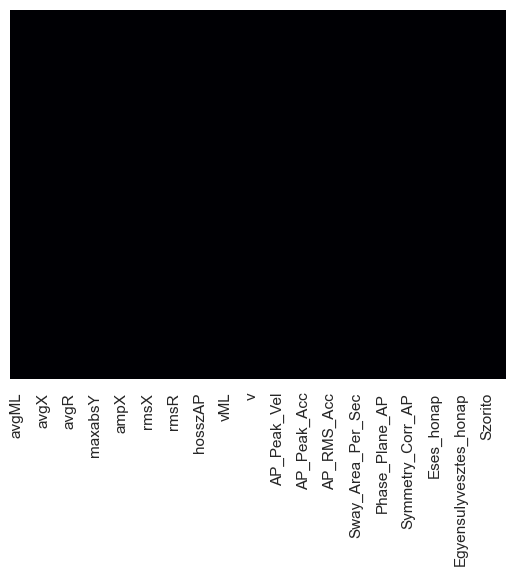

In [77]:
sns.heatmap(adatok_feldolgozva.isnull(), yticklabels=False, cbar=False, cmap='magma')
plt.savefig(r'C:\Users\gerge\OneDrive\Desktop\Egyetem\Szakdolgozat\szakdoga\figures\heatmap_eredmeny.pdf', dpi=300, bbox_inches='tight')

# Adatok elemzése
## Klinikai paraméterek ábrázolása

<Figure size 1000x600 with 0 Axes>

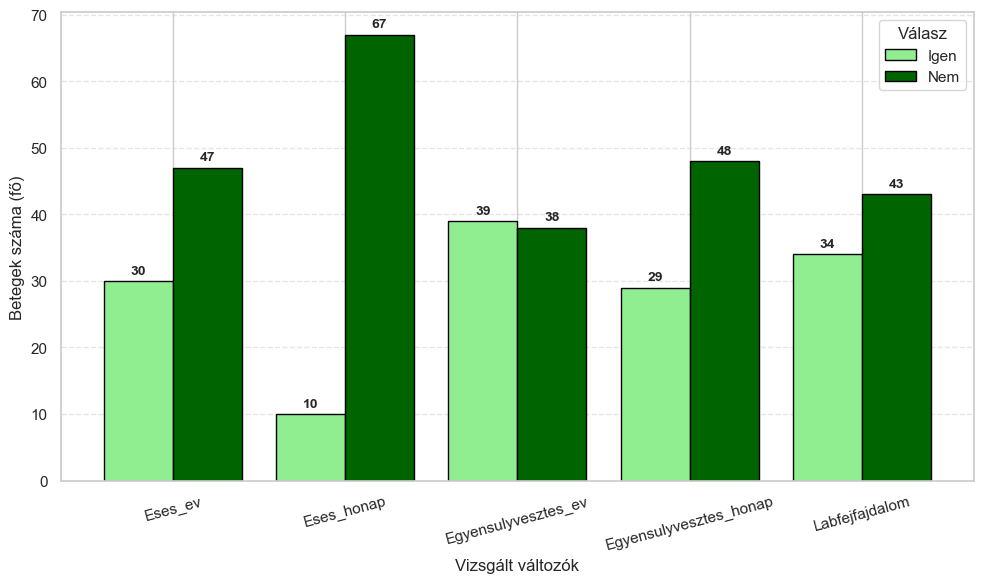

In [78]:
# ======================================================
# ÁBRÁZOLANDÓ OSZLOPOK
# ======================================================
cols_to_plot = [
    'Eses_ev', 'Eses_honap', 'Egyensulyvesztes_ev', 
    'Egyensulyvesztes_honap', 'Labfejfajdalom'
]

summary_df = adatok_feldolgozva[cols_to_plot].apply(pd.Series.value_counts).fillna(0).T

summary_df.columns = summary_df.columns.astype(str)

# ======================================================
# TÍPUSKONVERZIÓ
# ======================================================

name_map = {
    '0': 'Nem', '0.0': 'Nem', 'False': 'Nem', 'false': 'Nem',
    '1': 'Igen', '1.0': 'Igen', 'True': 'Igen', 'true': 'Igen'
}
summary_df = summary_df.rename(columns=name_map)
summary_df = summary_df.reindex(columns=['Igen', 'Nem'], fill_value=0)

# ======================================================
# VIZUALIZÁCIÓ
# ======================================================

plt.figure(figsize=(10, 6))

ax = summary_df.plot(kind='bar', width=0.8, color=['lightgreen', 'darkgreen'], edgecolor='black', figsize=(10, 6))

plt.ylabel("Betegek száma (fő)", fontsize=12)
plt.xlabel("Vizsgált változók", fontsize=12)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=10, fontweight='bold', 
                    xytext=(0, 3), textcoords='offset points')

plt.legend(title="Válasz")
plt.tight_layout()

plt.savefig(r'C:\Users\gerge\OneDrive\Desktop\Egyetem\Szakdolgozat\szakdoga\figures\klinikai.pdf', dpi=300, bbox_inches='tight')

plt.show()

A két esést jellemző változó közül csak az egyiket tartjuk meg kimeneti változónak. Az Eses_ev oszlopot tartjuk meg, mert egyenletesebb az eloszlása.

## Statisztikai elemzés

In [79]:
adatok_feldolgozva.to_excel("net_cop_adatok.xlsx", index=False)

# ======================================================
# ADATOK ELŐKÉSZÍTÉSE
# ======================================================
valid_eletkorok = adatok_feldolgozva[adatok_feldolgozva['Eletkor'] > 0]['Eletkor']

atlag_kor = valid_eletkorok.mean()
szoras_kor = valid_eletkorok.std()
min_kor=valid_eletkorok.min()
max_kor=valid_eletkorok.max()

print(f"Életkor: {atlag_kor:.2f} ± {szoras_kor:.2f} év")

adatok_excel = adatok_excel.drop(columns=['Eletkor'])

cols_to_drop = ['Eses_honap', 'Egyensulyvesztes_ev', 'Egyensulyvesztes_honap']
existing_cols = [c for c in cols_to_drop if c in adatok_feldolgozva.columns]
df_stat = adatok_feldolgozva.drop(columns=existing_cols).copy()

df_stat = df_stat.dropna(subset=['Eses_ev'])
df_stat['Group'] = df_stat['Eses_ev'].apply(lambda x: "1" if x > 0 else "0") 

exclude = ['Beteg', 'Lab', 'Group', 'Eses_ev', 'Subject', 'File']
features = [col for col in df_stat.select_dtypes(include=np.number).columns if col not in exclude]

# ======================================================
# STATISZTIKAI FÜGGVÉNYEK
# ======================================================

def get_cohen_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    v1, v2 = np.var(g1, ddof=1), np.var(g2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
    return (np.mean(g1) - np.mean(g2)) / pooled_std if pooled_std != 0 else 0

def analyze_feature(df, col, group_col='Group'):

    g_kontroll = df[df[group_col] == "0"][col].dropna()
    g_eso = df[df[group_col] == "1"][col].dropna()
    
    if len(g_kontroll) < 3 or len(g_eso) < 3:
        return None
    
    unique_vals = set(df[col].dropna().unique())
    is_binary = unique_vals.issubset({0, 1}) or unique_vals.issubset({0.0, 1.0})

    if is_binary:
        contingency = pd.crosstab(df[group_col], df[col])
        
        if contingency.shape != (2, 2):
            return None

        odds_ratio, p_val = stats.fisher_exact(contingency)
        
        k_count = g_kontroll.sum()
        k_n = len(g_kontroll)
        e_count = g_eso.sum()
        e_n = len(g_eso)
        
        res = {
            'Változó': col,
            'Kontroll': f"{int(k_count)}/{k_n} ({k_count/k_n*100:.1f}%)",
            'Eso': f"{int(e_count)}/{e_n} ({e_count/e_n*100:.1f}%)",
            'P_érték': p_val,
            'Hatásméret': odds_ratio,
            'Teszt': 'Fisher',
            'Típus': 'Bináris'
        }

    else:
        _, p_norm_k = stats.shapiro(g_kontroll)
        _, p_norm_e = stats.shapiro(g_eso)
        is_normal = (p_norm_k > 0.05) and (p_norm_e > 0.05)

        if is_normal:
            _, p_val = stats.ttest_ind(g_kontroll, g_eso, equal_var=False)
            test_type = "T-test"
        else:
            _, p_val = stats.mannwhitneyu(g_kontroll, g_eso)
            test_type = "Mann-Whitney"

        d_val = get_cohen_d(g_eso, g_kontroll)

        res = {
            'Változó': col,
            'Kontroll': f"{g_kontroll.mean():.2f} ± {g_kontroll.std():.2f}",
            'Eso': f"{g_eso.mean():.2f} ± {g_eso.std():.2f}",
            'P_érték': p_val,
            'Hatásméret': d_val,
            'Teszt': test_type,
            'Típus': 'Folytonos'
        }
        
    return res

# ======================================================
# ELEMZÉS
# ======================================================

results = []
for col in features:
    res = analyze_feature(df_stat, col)
    if res:
        results.append(res)

summary_df = pd.DataFrame(results).sort_values('P_érték')

print("\n--- STATISZTIKAI ÖSSZEFOGLALÓ ---")
print(summary_df[['Változó', 'P_érték', 'Hatásméret', 'Teszt']].to_string(index=False))

# ======================================================
# LATEX TÁBLÁZAT GENERÁLÁSA
# ======================================================

df_to_export = summary_df[['Változó', 'Kontroll', 'Eso', 'P_érték', 'Hatásméret', 'Teszt']].copy()

df_to_export['Változó'] = df_to_export['Változó'].astype(str).str.replace('_', r'\\_', regex=True)

df_to_export['P_str'] = df_to_export['P_érték'].map(lambda x: f"{x:.4f}" if x >= 0.001 else "<0.001")
df_to_export['Eff_str'] = df_to_export['Hatásméret'].map(lambda x: f"{x:.2f}")

def apply_latex_formatting(row):
    if row['P_érték'] < 0.05:
        row['Változó'] = f"\\textbf{{{row['Változó']}}}"
        row['P_out'] = f"\\textbf{{{row['P_str']}}}"
        row['Eff_out'] = f"\\textbf{{{row['Eff_str']}}}"
    else:
        row['P_out'] = row['P_str']
        row['Eff_out'] = row['Eff_str']
    return row

df_to_export = df_to_export.apply(apply_latex_formatting, axis=1)

final_table = df_to_export[['Változó', 'Kontroll', 'Eso', 'P_out', 'Eff_out', 'Teszt']]
final_table.columns = ['Változó', 'Kontroll', 'Eső', 'p-érték', 'Eff. (d/OR)', 'Teszt']

latex_code = final_table.to_latex(
    index=False,
    escape=False,
    caption="Statisztikai elemzés eredményei (OR: Odds Ratio bináris változóknál, d: Cohen-d folytonosnál)",
    label="tab:stats_results",
    column_format="l l l r r l",
    position="H"
)

print("\n--- LATEX KÓD ---")
print(latex_code)

Életkor: 81.25 ± 6.23 év

--- STATISZTIKAI ÖSSZEFOGLALÓ ---
                Változó  P_érték  Hatásméret        Teszt
            ML_Peak_Vel 0.001886    0.715037 Mann-Whitney
             ML_RMS_Acc 0.003505    0.601327 Mann-Whitney
            ML_Peak_Acc 0.010029    0.656476 Mann-Whitney
                      v 0.030200    0.514355 Mann-Whitney
            teljeshossz 0.030200    0.514346 Mann-Whitney
                hosszML 0.035310    0.507880 Mann-Whitney
                    vML 0.035766    0.507881 Mann-Whitney
            AP_Peak_Vel 0.057976    0.396961 Mann-Whitney
         Phase_Plane_AP 0.059371    0.456073 Mann-Whitney
             AP_RMS_Acc 0.060795    0.386648 Mann-Whitney
                   maxR 0.066772    0.483997 Mann-Whitney
                hosszAP 0.068340    0.416316 Mann-Whitney
                    vAP 0.068340    0.416329 Mann-Whitney
                   ampX 0.076639    0.471095 Mann-Whitney
         Phase_Plane_ML 0.080179    0.456858 Mann-Whitney
            

In [80]:
df_to_export = summary_df[['Változó', 'Kontroll', 'Eso', 'P_érték', 'Hatásméret', 'Teszt']].copy()

# ---------------------------------------------------------
# SZÖVEGES JAVÍTÁSOK
# ---------------------------------------------------------

df_to_export['Változó'] = df_to_export['Változó'].astype(str).str.replace('_', r'\_', regex=True)

for col in ['Kontroll', 'Eso']:
    df_to_export[col] = df_to_export[col].astype(str).str.replace('%', r'\%', regex=False)

# ---------------------------------------------------------
# JELÖLÉSEK HOZZÁADÁSA A TESZT TÍPUSA ALAPJÁN
# ---------------------------------------------------------
def add_test_symbol(row):
    if 'Mann-Whitney' in row['Teszt']:
        return row['Változó']

    elif 'T-test' in row['Teszt']:
        return row['Változó'] + r"$^{*}$"

    elif 'Fisher' in row['Teszt']:
        return row['Változó'] + r"$^{**}$"
    return row['Változó']

df_to_export['Változó'] = df_to_export.apply(add_test_symbol, axis=1)

# ---------------------------------------------------------
# 3. SZÁMOK FORMÁZÁSA
# ---------------------------------------------------------
df_to_export['P_str'] = df_to_export['P_érték'].map(lambda x: "<0.001" if x < 0.001 else f"{x:.4f}")
df_to_export['Eff_str'] = df_to_export['Hatásméret'].map(lambda x: f"{x:.2f}")

# ---------------------------------------------------------
# 4. FÉLKÖVÉR KIEMELÉS
# ---------------------------------------------------------
def apply_formatting(row):
    if row['P_érték'] < 0.05:
        row['Változó'] = f"\\textbf{{{row['Változó']}}}"
        row['P_out'] = f"\\textbf{{{row['P_str']}}}"
        row['Eff_out'] = f"\\textbf{{{row['Eff_str']}}}"
    else:
        row['P_out'] = row['P_str']
        row['Eff_out'] = row['Eff_str']
    return row

df_to_export = df_to_export.apply(apply_formatting, axis=1)

# ---------------------------------------------------------
# LATEX TÁBLÁZAT
# ---------------------------------------------------------
final_table = df_to_export[['Változó', 'Kontroll', 'Eso', 'P_out', 'Eff_out']]
final_table.columns = ['Változó', 'Kontroll', 'Eső', 'p-érték', 'Effekt (d/OR)']

latex_code = final_table.to_latex(
    index=False,
    escape=False,
    caption="Statisztikai eredmények összefoglalása. Jelmagyarázat: $^{**}$ Fisher-féle egzakt teszt, $^{*}$ T-próba, jelöletlen: Mann-Whitney U-teszt.",
    label="tab:statisztika_vegleges",
    column_format="l l l r r",
    position="H"
)

print(latex_code)

\begin{table}[H]
\caption{Statisztikai eredmények összefoglalása. Jelmagyarázat: $^{**}$ Fisher-féle egzakt teszt, $^{*}$ T-próba, jelöletlen: Mann-Whitney U-teszt.}
\label{tab:statisztika_vegleges}
\begin{tabular}{l l l r r}
\toprule
Változó & Kontroll & Eső & p-érték & Effekt (d/OR) \\
\midrule
\textbf{ML\_Peak\_Vel} & 23.87 ± 16.68 & 45.88 ± 44.81 & \textbf{0.0019} & \textbf{0.72} \\
\textbf{ML\_RMS\_Acc} & 11.85 ± 7.65 & 19.37 ± 17.63 & \textbf{0.0035} & \textbf{0.60} \\
\textbf{ML\_Peak\_Acc} & 70.61 ± 49.03 & 129.24 ± 129.68 & \textbf{0.0100} & \textbf{0.66} \\
\textbf{v} & 4.92 ± 2.39 & 6.74 ± 4.82 & \textbf{0.0302} & \textbf{0.51} \\
\textbf{teljeshossz} & 221.32 ± 107.43 & 303.11 ± 217.01 & \textbf{0.0302} & \textbf{0.51} \\
\textbf{hosszML} & 152.87 ± 92.62 & 227.81 ± 206.61 & \textbf{0.0353} & \textbf{0.51} \\
\textbf{vML} & 3.40 ± 2.06 & 5.06 ± 4.59 & \textbf{0.0358} & \textbf{0.51} \\
AP\_Peak\_Vel & 17.50 ± 11.67 & 22.22 ± 12.22 & 0.0580 & 0.40 \\
Phase\_Plane\_AP & 5.13 

## PCA

In [81]:
adatok_feldolgozva=adatok_feldolgozva.drop(columns=['Eses_honap', 'Egyensulyvesztes_ev', 'Egyensulyvesztes_honap'])
# ==============================================================================
# BEÁLLÍTÁSOK
# ==============================================================================
TARGET_COL = 'Eses_ev'
VARIANCE_TO_KEEP = 0.95
TOP_N_FEATURES = 5

df_pca_input = adatok_feldolgozva.copy()
X = df_pca_input.select_dtypes(include=['float64', 'int64'])

if TARGET_COL in X.columns:
    y = X[TARGET_COL]
    X = X.drop(columns=[TARGET_COL])
else:
    print(f"A(z) '{TARGET_COL}' célváltozó nem található a numerikus oszlopok között.")
    y = None

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=VARIANCE_TO_KEEP)
X_pca_array = pca.fit_transform(X_scaled)

num_components = X_pca_array.shape[1]
pc_columns = [f'PC{i+1}' for i in range(num_components)]
df_pca_result = pd.DataFrame(data=X_pca_array, columns=pc_columns)

if y is not None:
    df_pca_result[TARGET_COL] = y.values

# ==============================================================================
# FEATURE IMPORTANCE
# ==============================================================================
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=pc_columns, 
    index=X.columns
)


for i, col in enumerate(pc_columns):
    top_features = loadings[col].abs().sort_values(ascending=False).head(TOP_N_FEATURES)
    
    explained_var = pca.explained_variance_ratio_[i]
    print(f"\n{col} (Variancia {explained_var:.1%}-a)")
    
    for feature_name, _ in top_features.items():
        raw_val = loadings.loc[feature_name, col]
        print(f"   {feature_name}: {raw_val:.4f}")


PC1 (Variancia 58.3%-a)
   teljeshossz: 0.2206
   v: 0.2206
   Confidence_Ellipse_Area: 0.2201
   Sway_Area_Per_Sec: 0.2180
   hosszML: 0.2146

PC2 (Variancia 12.8%-a)
   AP_RMS_Acc: 0.3038
   Phase_Plane_AP: 0.2922
   vAP: 0.2766
   hosszAP: 0.2766
   AP_Peak_Acc: 0.2574

PC3 (Variancia 5.4%-a)
   avgML: 0.4819
   AP_Peak_Acc: -0.4168
   AP_Peak_Vel: -0.4018
   Szorito: 0.2911
   avgAP: -0.2385

PC4 (Variancia 3.9%-a)
   Symmetry_Corr_AP: 0.4033
   Labfejfajdalom: 0.3714
   ML_Peak_Acc: 0.2730
   maxabsY: -0.2602
   ML_Peak_Vel: 0.2551

PC5 (Variancia 3.7%-a)
   Szorito: 0.4917
   Symmetry_Corr_AP: -0.3630
   Labfejfajdalom: -0.3598
   Symmetry_Corr_ML: -0.2646
   ML_Peak_Acc: 0.2205

PC6 (Variancia 3.6%-a)
   Symmetry_Corr_ML: 0.6443
   avgAP: 0.4905
   Szorito: 0.3824
   avgML: -0.3026
   Labfejfajdalom: -0.1939

PC7 (Variancia 2.7%-a)
   avgAP: 0.7189
   Symmetry_Corr_ML: -0.5541
   AP_Peak_Vel: -0.1896
   AP_Peak_Acc: -0.1843
   Szorito: -0.1397

PC8 (Variancia 2.5%-a)
   Labfejf

## LDA

                         Fontosság
rmsX                     35.966274
rmsR                     31.464618
avgR                     20.067129
avgX                     18.251923
maxR                     11.752504
maxabsX                   9.505796
Phase_Plane_AP            9.127642
Sway_Area_Per_Sec         7.612220
rmsY                      5.688089
Confidence_Ellipse_Area   5.243695


C:\Users\gerge\AppData\Local\Temp\ipykernel_22228\4197874196.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x=celvaltozo, y='LD1', data=df_lda, jitter=True, palette='Set1')


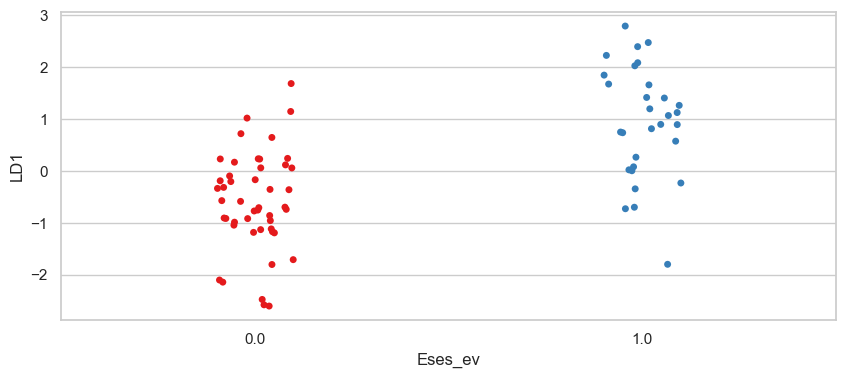

In [82]:
# ======================================================
# BEÁLLÍTÁSOK
# ======================================================
celvaltozo = 'Eses_ev'
X = adatok_feldolgozva.select_dtypes(include=['float64', 'int64', 'bool']).drop(columns=[celvaltozo])
y = adatok_feldolgozva[celvaltozo]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ======================================================
# LDA ALKALMAZÁSA
# ======================================================
lda = LinearDiscriminantAnalysis()
X_lda = lda.fit_transform(X_scaled, y)

df_lda = pd.DataFrame(X_lda, columns=[f'LD{i+1}' for i in range(X_lda.shape[1])])
df_lda[celvaltozo] = y.values

lda_loadings = pd.DataFrame(
    np.abs(lda.coef_[0]), 
    index=X.columns, 
    columns=['Fontosság']
).sort_values(by='Fontosság', ascending=False)

print(lda_loadings.head(10))

# ======================================================
# VIZUALIZÁCIÓ
# ======================================================
plt.figure(figsize=(10, 4))
sns.stripplot(x=celvaltozo, y='LD1', data=df_lda, jitter=True, palette='Set1')
plt.show()

# Beállítások

In [83]:
# ======================================================
# BEÁLLÍTÁSOK
# ======================================================
X_input = adatok_feldolgozva.drop(columns=['Eses_ev'])
y_input = adatok_feldolgozva['Eses_ev'].astype(int)

features=4

# ==============================================================================
# FISHER ÉS MRMR DEFINIÁLÁSA
# ==============================================================================

def fisher_score_func(X, y):
    if isinstance(X, pd.DataFrame): X = X.values
    if isinstance(y, pd.Series): y = y.values
    
    classes = np.unique(y)
    mu_total = np.mean(X, axis=0)
    
    c1 = X[y == classes[0]]
    c2 = X[y == classes[1]]
    
    mu1 = np.mean(c1, axis=0)
    mu2 = np.mean(c2, axis=0)
    
    var1 = np.var(c1, axis=0)
    var2 = np.var(c2, axis=0)
    
    fisher = ((mu1 - mu2)**2) / (var1 + var2 + 1e-9)
    return fisher

class MRMRSelector(BaseEstimator, TransformerMixin):
    def __init__(self, k=10):
        self.k = k
        self.selected_indices_ = []
        self.feature_names_in_ = []

    def fit(self, X, y):
        if hasattr(X, 'columns'):
            self.feature_names_in_ = list(X.columns)
            X_arr = X.values
        else:
            X_arr = X
            self.feature_names_in_ = [f"Feat_{i}" for i in range(X.shape[1])]
            
        n_features = X_arr.shape[1]
        
        F, _ = f_classif(X_arr, y)
        
        selected = []
        candidates = list(range(n_features))
        
        best_first = candidates[np.argmax(F[candidates])]
        selected.append(best_first)
        candidates.remove(best_first)
        
        for _ in range(self.k - 1):
            best_score = -np.inf
            best_feat = -1
            
            curr_X = X_arr[:, selected]
            
            for feat in candidates:
                relevance = F[feat]
                corrs = np.abs(np.corrcoef(X_arr[:, feat], curr_X.T)[0, 1:])
                redundancy = np.mean(corrs) if len(corrs) > 0 else 0
                
                score = relevance / (redundancy + 0.001)
                
                if score > best_score:
                    best_score = score
                    best_feat = feat
            
            if best_feat != -1:
                selected.append(best_feat)
                candidates.remove(best_feat)
                
        self.selected_indices_ = selected
        return self

    def transform(self, X):
        if hasattr(X, 'iloc'):
            return X.iloc[:, self.selected_indices_]
        return X[:, self.selected_indices_]

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_in_)[self.selected_indices_]

# ==============================================================================
# REDUCER DEFINIÁLÁSA
# ==============================================================================

def get_reducer(mode):
    base_estimator = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)
    base_lasso = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, class_weight='balanced', random_state=42)

    if mode == "LDA":
        return LDA(n_components=features)
    
    elif mode == "PCA":
        return PCA(n_components=5)
    
    elif mode == "SELECT_BEST":
        return SelectKBest(f_classif, k=features)
    
    elif mode == "FISHER":
        return SelectKBest(score_func=fisher_score_func, k=features)
    
    elif mode == "MRMR":
        return MRMRSelector(k=features)

    elif mode == "HYBRID":
        # Mutual Info + LASSO
        return Pipeline([
            ('filter_mi', SelectKBest(mutual_info_classif, k=features)),
            ('lasso_select', SelectFromModel(base_lasso))
        ])
    
    elif mode == "HYBRID_2":
        # Mutual Info + RFE
        return Pipeline([
            ('filter', SelectKBest(mutual_info_classif, k=features)),
            ('wrapper', RFE(estimator=base_estimator, n_features_to_select=features))
        ])

    elif mode == "EMBEDDED_LASSO":
        return SelectFromModel(base_lasso, max_features=features, threshold=-np.inf)

    elif mode == "WRAPPER_SFS":
        from sklearn.feature_selection import SequentialFeatureSelector as SklearnSFS
        return SklearnSFS(estimator=base_estimator, n_features_to_select=features, direction='forward')
        
    elif mode == "WRAPPER_SBS":
        from sklearn.feature_selection import SequentialFeatureSelector as SklearnSFS
        return SklearnSFS(estimator=base_estimator, n_features_to_select=features, direction='backward')
    
    elif mode == "HYBRID_FISHER_SBS":
        # Fisher + SBS
        from sklearn.feature_selection import SequentialFeatureSelector as SklearnSFS
        return Pipeline([
            ('filter_fisher', SelectKBest(score_func=fisher_score_func, k=10)),
            ('wrapper_sbs', SklearnSFS(estimator=base_estimator, n_features_to_select=features, direction='backward'))
        ])
    
    elif mode == "HYBRID_FISHER_SFS":
        # Fisher + SFS
        from sklearn.feature_selection import SequentialFeatureSelector as SklearnSFS
        return Pipeline([
            ('filter_fisher', SelectKBest(score_func=fisher_score_func, k=10)),
            ('wrapper_sfs', SklearnSFS(estimator=base_estimator, n_features_to_select=features, direction='forward'))
        ])
    
    elif mode == "HYBRID_ENSEMBLE":
        # Fisher az együttes tanulás módszerek számára
        return Pipeline([
        ('filter_fisher', SelectKBest(score_func=fisher_score_func, k=15)), # Vagy SelectKBest(fisher, k=15)
        ('passthrough', 'passthrough')  # Itt nem kell SFS, az RF maga a wrapper!
    ])
        
    elif mode == "HYBRID_MRMR_SFS":
        # MRMR + SFS
        from sklearn.feature_selection import SequentialFeatureSelector as SklearnSFS
        return Pipeline([
            ('filter_mrmr', MRMRSelector(k=15)),
            ('wrapper_sfs', SklearnSFS(estimator=base_estimator, n_features_to_select=5, direction='forward'))
        ])
        
        
    elif mode == "HYBRID_LASSO_SBS":
        # 1. LASSO + SFS
        from sklearn.feature_selection import SequentialFeatureSelector as SklearnSFS
        return Pipeline([
            ('embedded_lasso', SelectFromModel(base_lasso)),
            ('wrapper_sbs', SklearnSFS(estimator=base_estimator, n_features_to_select=5, direction='backward'))
        ])

    elif mode == "ORIGINAL":
        return 'passthrough'
    
    else:
        raise ValueError(f"Unknown mode: {mode}")
    

FEATURE_SELECTION_METHOD="HYBRID_FISHER_SFS"

# Modellek
## LSVM


>> OPTIMÁLIS KÜSZÖB: 0.5412
Tanulási Pont.:  66.2%
Teszt Pontosság: 64.9%
AUC érték:       0.4787
F1-érték:        0.2286
Szenzitivitás:   13.3%
Specificitás:    97.9%
MCC:             0.2218


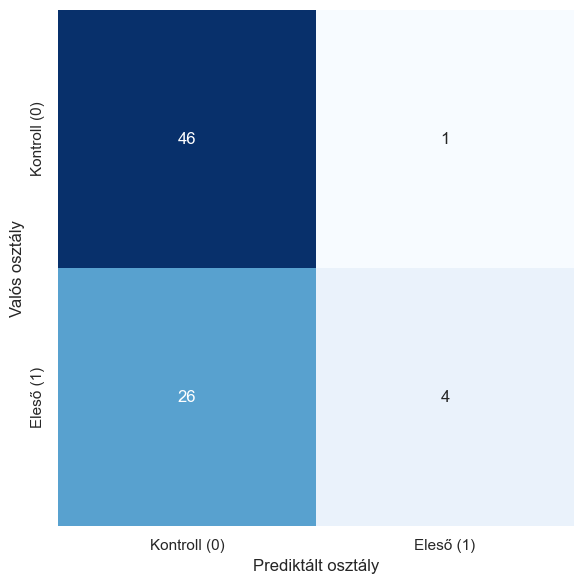

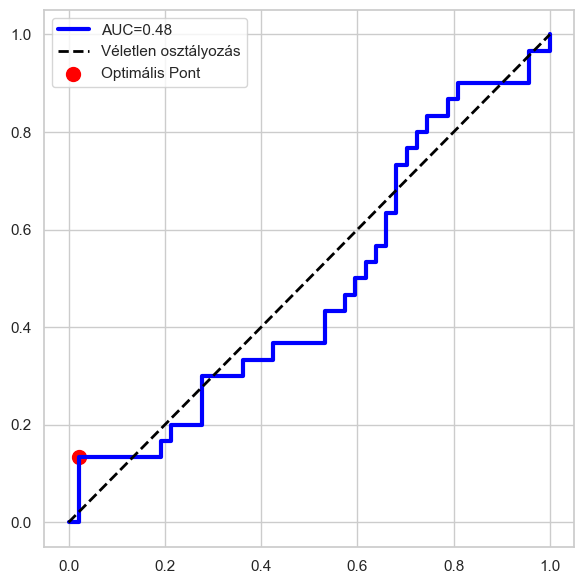

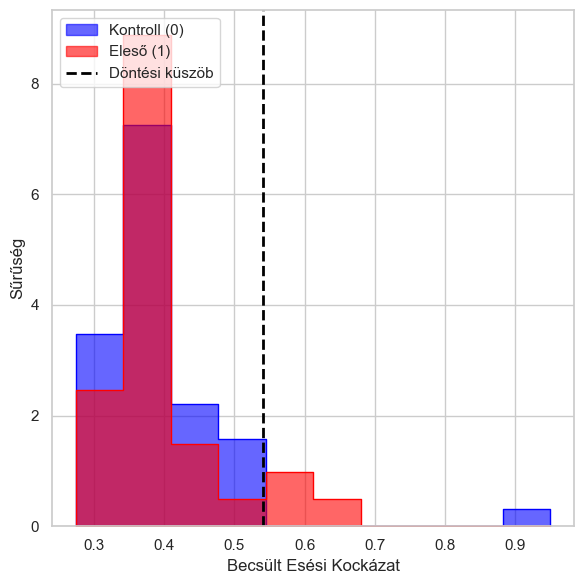

In [93]:
# ==============================================================================
# KONFIGURÁCIÓ
# ==============================================================================
SVM_LIN_MODE = FEATURE_SELECTION_METHOD 

THRESHOLD_MODE = "OPTIMAL"
CUSTOM_VAL = 0.40

current_reducer = get_reducer(SVM_LIN_MODE)

pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('reducer', current_reducer),
    ('classifier', SVC(kernel='linear', C=1, probability=True, class_weight='balanced', random_state=42))
])
# ==============================================================================
# LOOCV
# ==============================================================================
loo = LeaveOneOut()
y_true, y_probs = [], []

for train_idx, test_idx in loo.split(X_input):
    X_train, X_test = X_input.iloc[train_idx], X_input.iloc[test_idx]
    y_train, y_test = y_input.iloc[train_idx], y_input.iloc[test_idx]
    
    pipe_svm.fit(X_train, y_train)
    
    try:
        # Helyes osztály index keresése (hogy biztosan az '1'-es valószínűségét kapjuk)
        model_classes = pipe_svm.named_steps['classifier'].classes_
        target_idx = np.where(model_classes == 1)[0][0]
        prob = pipe_svm.predict_proba(X_test)[0, target_idx]
    except:
        prob = 0.0
        
    y_true.append(y_test.values[0])
    y_probs.append(prob)

# ==============================================================================
# KÜSZÖB SZÁMÍTÁSA
# ==============================================================================
fpr, tpr, thresholds = roc_curve(y_true, y_probs)

if THRESHOLD_MODE == "OPTIMAL":
    J = tpr - fpr
    ix = np.argmax(J)
    final_threshold = thresholds[ix]
    print(f"\n>> OPTIMÁLIS KÜSZÖB: {final_threshold:.4f}")
    
elif THRESHOLD_MODE == "FIXED":
    final_threshold = CUSTOM_VAL
    print(f"\n>> MANUÁLIS BEÁLLÍTÁS: {final_threshold:.4f}")
else:
    final_threshold = 0.5
    print(f"\n>> DEFAULT MÓD: Küszöb = 0.5")

pipe_svm.fit(X_input, y_input)

model_classes = pipe_svm.named_steps['classifier'].classes_
target_idx = np.where(model_classes == 1)[0][0]
y_train_probs = pipe_svm.predict_proba(X_input)[:, target_idx]


y_train_pred = [1 if p >= final_threshold else 0 for p in y_train_probs]
train_acc = accuracy_score(y_input, y_train_pred)

# ==============================================================================
# KIÉRTÉKELÉS
# ==============================================================================
y_pred = [1 if p >= final_threshold else 0 for p in y_probs]

test_acc = accuracy_score(y_true, y_pred)
roc_auc = auc(fpr, tpr)
mcc = matthews_corrcoef(y_true, y_pred)
sens = recall_score(y_true, y_pred, pos_label=1)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
spec = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = f1_score(y_true, y_pred)

print(f"Tanulási Pont.:  {train_acc:.1%}")
print(f"Teszt Pontosság: {test_acc:.1%}")
print(f"AUC érték:       {roc_auc:.4f}")
print(f"F1-érték:        {f1:.4f}")
print(f"Szenzitivitás:   {sens:.1%}")
print(f"Specificitás:    {spec:.1%}")
print(f"MCC:             {mcc:.4f}")

# ==============================================================================
# VIZUALIZÁCIÓ
# ==============================================================================
sns.set(style="whitegrid")
labels = ['Kontroll (0)', 'Eleső (1)']

# KONFÚZIÓS MÁTRIX
plt.figure(figsize=(6, 6))
sns.heatmap(confusion_matrix(y_true, y_pred), 
            annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=labels, yticklabels=labels)
plt.xlabel(f'Prediktált osztály')
plt.ylabel('Valós osztály')
plt.tight_layout()
plt.show()

# ROC GÖRBE
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=3, label=f'AUC={roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', lw=2, label='Véletlen osztályozás')
if THRESHOLD_MODE == "OPTIMAL":
    plt.scatter(fpr[ix], tpr[ix], marker='o', color='red', s=100, label='Optimális Pont')
plt.legend()
plt.tight_layout()
plt.show()

# VALÓSZÍNŰSÉG ELOSZLÁS
plt.figure(figsize=(6, 6))
plot_data = pd.DataFrame({'Prob': y_probs, 'True': y_true})
plot_data['True'] = plot_data['True'].map({0: 'Kontroll (0)', 1: 'Eleső (1)'})

ax = sns.histplot(data=plot_data, x='Prob', hue='True', 
                 element="step", stat="density", common_norm=False, 
                 palette={'Kontroll (0)': 'blue', 'Eleső (1)': 'red'},
                 bins=10, alpha=0.6, legend=False)

plt.axvline(final_threshold, color='black', linestyle='--', linewidth=2)

blue_patch = mpatches.Patch(color='blue', alpha=0.6, label='Kontroll (0)')
red_patch = mpatches.Patch(color='red', alpha=0.6, label='Eleső (1)')

threshold_line = Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Döntési küszöb')

plt.legend(handles=[blue_patch, red_patch, threshold_line], loc='upper left', frameon=True)

plt.xlabel('Becsült Esési Kockázat')
plt.ylabel('Sűrűség')
plt.tight_layout()
plt.show()

## SMOTE-LSVM


>> OPTIMÁLIS KÜSZÖB: 0.4379
Tanulási Pont.:  57.1%
Teszt Pontosság: 61.0%
AUC érték:       0.6092
F1-érték:        0.6053
Szenzitivitás:   76.7%
Specificitás:    51.1%
MCC:             0.2757


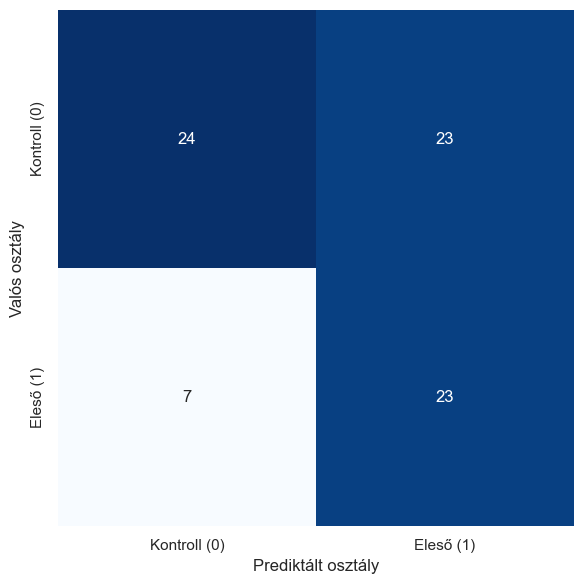

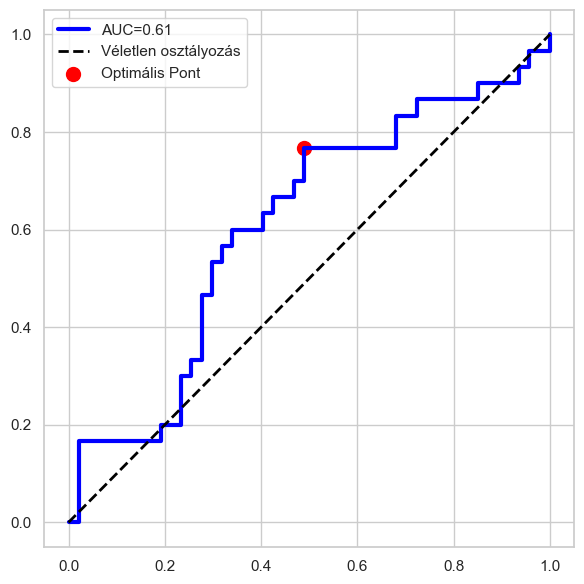

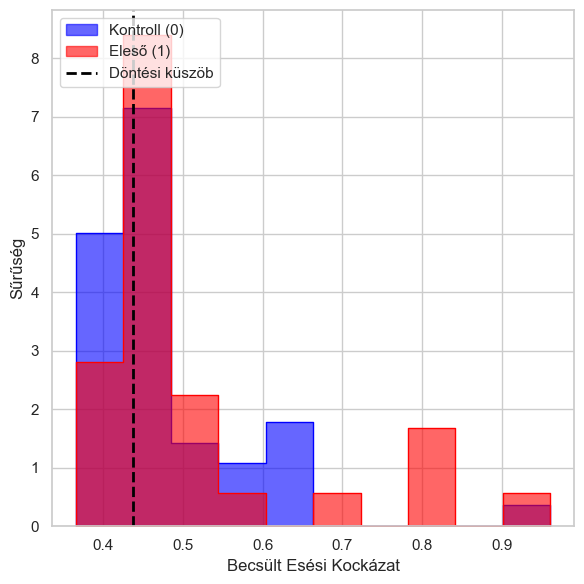

In [94]:
# ==============================================================================
# KONFIGURÁCIÓ
# ==============================================================================
SVM_LIN_MODE = FEATURE_SELECTION_METHOD 

THRESHOLD_MODE = "OPTIMAL"
CUSTOM_VAL = 0.40

# 1. Reducer lekérése
current_reducer = get_reducer(SVM_LIN_MODE)

# Pipeline dinamikus építése
steps = [('scaler', StandardScaler())]

if isinstance(current_reducer, SklearnPipeline):
    steps.extend(current_reducer.steps)
elif current_reducer != 'passthrough':
    steps.append(('reducer', current_reducer))

steps.append(('smote', SMOTE(random_state=42)))
steps.append(('classifier', SVC(kernel='linear', C=1, probability=True, random_state=42)))

pipe_svm = ImbPipeline(steps)

# ==============================================================================
# LOOCV
# ==============================================================================
loo = LeaveOneOut()
y_true, y_probs = [], []

for train_idx, test_idx in loo.split(X_input):
    X_train, X_test = X_input.iloc[train_idx], X_input.iloc[test_idx]
    y_train, y_test = y_input.iloc[train_idx], y_input.iloc[test_idx]
    
    pipe_svm.fit(X_train, y_train)
    
    try:
        model_classes = pipe_svm.named_steps['classifier'].classes_
        target_idx = np.where(model_classes == 1)[0][0]
        prob = pipe_svm.predict_proba(X_test)[0, target_idx]
    except:
        prob = 0.0
        
    y_true.append(y_test.values[0])
    y_probs.append(prob)

# ==============================================================================
# KÜSZÖB SZÁMÍTÁSA
# ==============================================================================
fpr, tpr, thresholds = roc_curve(y_true, y_probs)

if THRESHOLD_MODE == "OPTIMAL":
    J = tpr - fpr
    ix = np.argmax(J)
    final_threshold = thresholds[ix]
    print(f"\n>> OPTIMÁLIS KÜSZÖB: {final_threshold:.4f}")
    
elif THRESHOLD_MODE == "FIXED":
    final_threshold = CUSTOM_VAL
    print(f"\n>> MANUÁLIS BEÁLLÍTÁS: {final_threshold:.4f}")
else:
    final_threshold = 0.5
    print(f"\n>> DEFAULT MÓD: Küszöb = 0.5")

pipe_svm.fit(X_input, y_input)

model_classes = pipe_svm.named_steps['classifier'].classes_
target_idx = np.where(model_classes == 1)[0][0]
y_train_probs = pipe_svm.predict_proba(X_input)[:, target_idx]

y_train_pred = [1 if p >= final_threshold else 0 for p in y_train_probs]
train_acc = accuracy_score(y_input, y_train_pred)

# ==============================================================================
# KIÉRTÉKELÉS
# ==============================================================================
y_pred = [1 if p >= final_threshold else 0 for p in y_probs]

test_acc = accuracy_score(y_true, y_pred)
roc_auc = auc(fpr, tpr)
mcc = matthews_corrcoef(y_true, y_pred)
sens = recall_score(y_true, y_pred, pos_label=1)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
spec = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = f1_score(y_true, y_pred)

print(f"Tanulási Pont.:  {train_acc:.1%}")
print(f"Teszt Pontosság: {test_acc:.1%}")
print(f"AUC érték:       {roc_auc:.4f}")
print(f"F1-érték:        {f1:.4f}")
print(f"Szenzitivitás:   {sens:.1%}")
print(f"Specificitás:    {spec:.1%}")
print(f"MCC:             {mcc:.4f}")

# ==============================================================================
# VIZUALIZÁCIÓ
# ==============================================================================
sns.set(style="whitegrid")
labels = ['Kontroll (0)', 'Eleső (1)']

# KONFÚZIÓS MÁTRIX
plt.figure(figsize=(6, 6))
sns.heatmap(confusion_matrix(y_true, y_pred), 
            annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Prediktált osztály')
plt.ylabel('Valós osztály')
plt.tight_layout()
plt.show()

# ROC GÖRBE
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=3, label=f'AUC={roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', lw=2, label='Véletlen osztályozás')
if THRESHOLD_MODE == "OPTIMAL":
    plt.scatter(fpr[ix], tpr[ix], marker='o', color='red', s=100, label='Optimális Pont')
plt.legend()
plt.tight_layout()
plt.show()

# VALÓSZÍNŰSÉG ELOSZLÁS
plt.figure(figsize=(6, 6))
plot_data = pd.DataFrame({'Prob': y_probs, 'True': y_true})
plot_data['True'] = plot_data['True'].map({0: 'Kontroll (0)', 1: 'Eleső (1)'})

ax = sns.histplot(data=plot_data, x='Prob', hue='True', 
                  element="step", stat="density", common_norm=False, 
                  palette={'Kontroll (0)': 'blue', 'Eleső (1)': 'red'},
                  bins=10, alpha=0.6, legend=False)

plt.axvline(final_threshold, color='black', linestyle='--', linewidth=2)

blue_patch = mpatches.Patch(color='blue', alpha=0.6, label='Kontroll (0)')
red_patch = mpatches.Patch(color='red', alpha=0.6, label='Eleső (1)')
threshold_line = Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Döntési küszöb')

plt.legend(handles=[blue_patch, red_patch, threshold_line], loc='upper left', frameon=True)

plt.xlabel('Becsült Esési Kockázat')
plt.ylabel('Sűrűség')
plt.tight_layout()
plt.show()

## RBF-LSVM


>> DURVA OPTIMUM: C=0.5000, gamma=0.1250

>> FINOM OPTIMUM: C=0.7071, gamma=0.0625

>> OPTIMÁLIS KÜSZÖB: 0.3287
Tanulási Pont.:  57.1%
Teszt Pontosság: 55.8%
AUC érték:       0.5837
F1-érték:        0.6136
Szenzitivitás:   90.0%
Specificitás:    34.0%
MCC:             0.2720


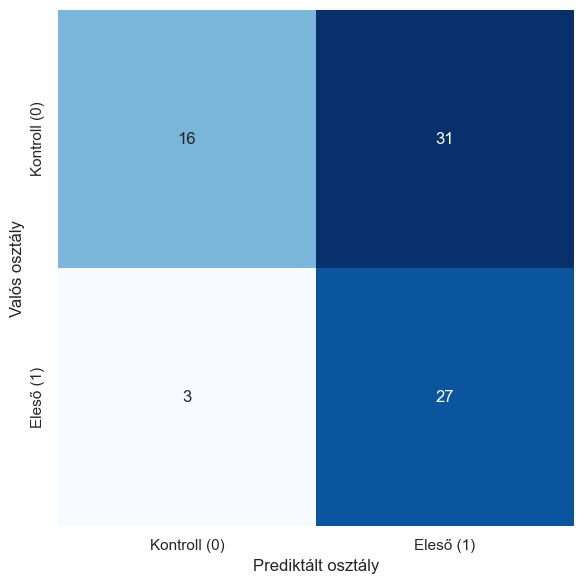

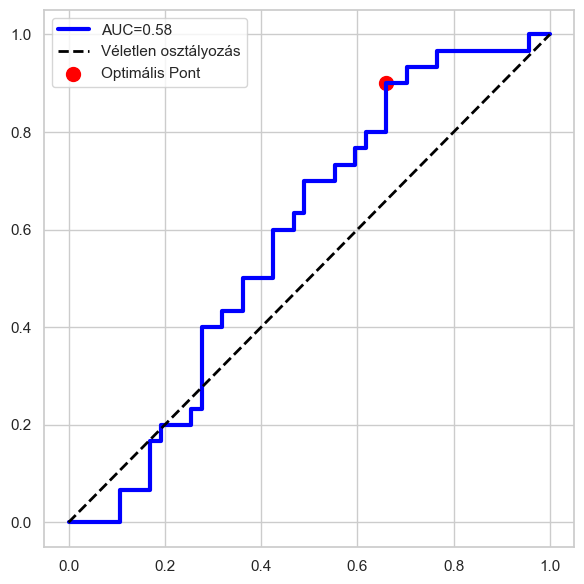

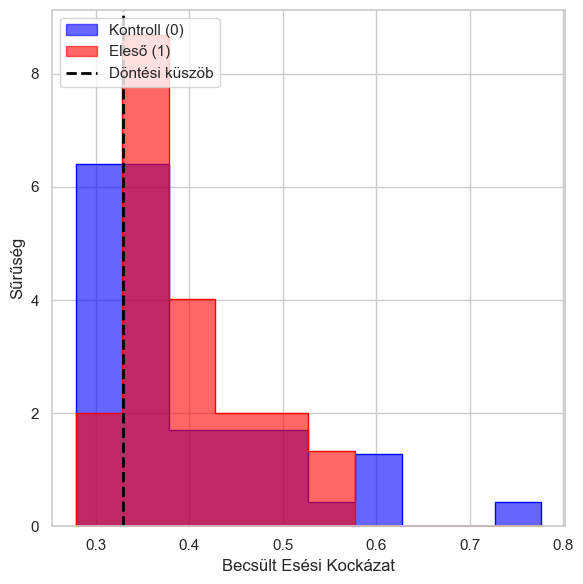

In [ ]:
# ==============================================================================
# KONFIGURÁCIÓ
# ==============================================================================
SVM_MODE = FEATURE_SELECTION_METHOD
THRESHOLD_MODE = "OPTIMAL" 
CUSTOM_VAL = 0.40

# 1. Reducer lekérése
current_reducer = get_reducer(SVM_MODE)

# 2. Pipeline Alapstruktúra felépítése
steps = [('scaler', StandardScaler())]

if isinstance(current_reducer, SklearnPipeline):
    steps.extend(current_reducer.steps)
elif current_reducer != 'passthrough':
    steps.append(('reducer', current_reducer))

steps.append(('classifier', SVC(
    kernel='rbf', probability=True, class_weight='balanced', random_state=42
)))

pipe_base = Pipeline(steps)

# ==============================================================================
# HIPERPARAMÉTER OPTIMALIZÁLÁS
# ==============================================================================

# DURVA KERESÉS
coarse_param_grid = {
    'classifier__C': [2**i for i in range(-5, 8, 2)],
    'classifier__gamma': [2**i for i in range(-15, 1, 2)]
}

gs_coarse = GridSearchCV(
    estimator=pipe_base,
    param_grid=coarse_param_grid,
    scoring='matthews_corrcoef', 
    cv=5, 
    n_jobs=-1
)

gs_coarse.fit(X_input, y_input)

best_c_coarse = gs_coarse.best_params_['classifier__C']
best_gamma_coarse = gs_coarse.best_params_['classifier__gamma']

print(f"\n>> DURVA KERESÉS: C={best_c_coarse:.4f}, gamma={best_gamma_coarse:.4f}")

# --- 2. LÉPÉS: FINE GRID (FINOMHANGOLÁS) ---
c_exp = np.log2(best_c_coarse)
gamma_exp = np.log2(best_gamma_coarse)

fine_param_grid = {
    'classifier__C': [2**i for i in np.arange(c_exp - 1, c_exp + 1.25, 0.25)],
    'classifier__gamma': [2**i for i in np.arange(gamma_exp - 1, gamma_exp + 1.25, 0.25)]
}

gs_svm = GridSearchCV(
    estimator=pipe_base,
    param_grid=fine_param_grid,
    scoring='matthews_corrcoef', 
    cv=5, 
    n_jobs=-1
)

gs_svm.fit(X_input, y_input)

best_c_fine = gs_svm.best_params_['classifier__C']
best_gamma_fine = gs_svm.best_params_['classifier__gamma']

print(f"\n>> OPTIMÁLIS HIPERPARAMÉTEREK: C={best_c_fine:.4f}, gamma={best_gamma_fine:.4f}")

# Végleges modell mentése
pipe_svm_rbf = gs_svm.best_estimator_


# ==============================================================================
# LOOCV
# ==============================================================================
loo = LeaveOneOut()
y_true, y_probs = [], []

for train_idx, test_idx in loo.split(X_input):
    X_train, X_test = X_input.iloc[train_idx], X_input.iloc[test_idx]
    y_train, y_test = y_input.iloc[train_idx], y_input.iloc[test_idx]
    
    pipe_svm_rbf.fit(X_train, y_train)
    
    try:
        model_classes = pipe_svm_rbf.named_steps['classifier'].classes_
        target_idx = np.where(model_classes == 1)[0][0]
        prob = pipe_svm_rbf.predict_proba(X_test)[0, target_idx]
    except:
        prob = 0.0
        
    y_true.append(y_test.values[0])
    y_probs.append(prob)

# ==============================================================================
# KÜSZÖB SZÁMÍTÁSA
# ==============================================================================
fpr, tpr, thresholds = roc_curve(y_true, y_probs)

if THRESHOLD_MODE == "OPTIMAL":
    J = tpr - fpr
    ix = np.argmax(J)
    final_threshold = thresholds[ix]
    print(f"\n>> OPTIMÁLIS KÜSZÖB: {final_threshold:.4f}")
    
elif THRESHOLD_MODE == "FIXED":
    final_threshold = CUSTOM_VAL
    print(f"\n>> MANUÁLIS BEÁLLÍTÁS: {final_threshold:.4f}")
else:
    final_threshold = 0.5
    print(f"\n>> DEFAULT MÓD: Küszöb = 0.5")

pipe_svm_rbf.fit(X_input, y_input)

model_classes = pipe_svm_rbf.named_steps['classifier'].classes_
target_idx = np.where(model_classes == 1)[0][0]
y_train_probs = pipe_svm_rbf.predict_proba(X_input)[:, target_idx]

y_train_pred = [1 if p >= final_threshold else 0 for p in y_train_probs]
train_acc = accuracy_score(y_input, y_train_pred)

# ==============================================================================
# KIÉRTÉKELÉS
# ==============================================================================
y_pred = [1 if p >= final_threshold else 0 for p in y_probs]

test_acc = accuracy_score(y_true, y_pred)
roc_auc = auc(fpr, tpr)
mcc = matthews_corrcoef(y_true, y_pred)
sens = recall_score(y_true, y_pred, pos_label=1)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
spec = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = f1_score(y_true, y_pred)

print(f"Tanulási Pont.:  {train_acc:.1%}")
print(f"Teszt Pontosság: {test_acc:.1%}")
print(f"AUC érték:       {roc_auc:.4f}")
print(f"F1-érték:        {f1:.4f}")
print(f"Szenzitivitás:   {sens:.1%}")
print(f"Specificitás:    {spec:.1%}")
print(f"MCC:             {mcc:.4f}")

# ==============================================================================
# VIZUALIZÁCIÓ
# ==============================================================================
sns.set(style="whitegrid")
labels = ['Kontroll (0)', 'Eleső (1)']

# KONFÚZIÓS MÁTRIX
plt.figure(figsize=(6, 6))
sns.heatmap(confusion_matrix(y_true, y_pred), 
            annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Prediktált osztály')
plt.ylabel('Valós osztály')
plt.tight_layout()
plt.show()

# ROC GÖRBE
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=3, label=f'AUC={roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', lw=2, label='Véletlen osztályozás')
if THRESHOLD_MODE == "OPTIMAL":
    plt.scatter(fpr[ix], tpr[ix], marker='o', color='red', s=100, label='Optimális Pont')
plt.legend()
plt.tight_layout()
plt.show()

# VALÓSZÍNŰSÉG ELOSZLÁS
plt.figure(figsize=(6, 6))
plot_data = pd.DataFrame({'Prob': y_probs, 'True': y_true})
plot_data['True'] = plot_data['True'].map({0: 'Kontroll (0)', 1: 'Eleső (1)'})

ax = sns.histplot(data=plot_data, x='Prob', hue='True', 
                  element="step", stat="density", common_norm=False, 
                  palette={'Kontroll (0)': 'blue', 'Eleső (1)': 'red'},
                  bins=10, alpha=0.6, legend=False)

plt.axvline(final_threshold, color='black', linestyle='--', linewidth=2)

blue_patch = mpatches.Patch(color='blue', alpha=0.6, label='Kontroll (0)')
red_patch = mpatches.Patch(color='red', alpha=0.6, label='Eleső (1)')
threshold_line = Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Döntési küszöb')

plt.legend(handles=[blue_patch, red_patch, threshold_line], loc='upper left', frameon=True)

plt.xlabel('Becsült Esési Kockázat')
plt.ylabel('Sűrűség')
plt.tight_layout()
plt.show()

## Logisztikus regresszió

Logisztikus Regresszió indítása (HYBRID_FISHER_SFS)...
Küszöb mód: OPTIMAL

>> AUTOMATIKUS OPTIMUM: 0.4778

=== LOGISZTIKUS REGRESSZIÓ (HYBRID_FISHER_SFS) ===
Küszöb:          0.4778
Tanulási Pont.:  58.4%
Teszt Pontosság: 58.4%
AUC érték:       0.6376
F1-érték:        0.6098
Szenzitivitás:   83.3%
Specifikusság:   42.6%
MCC:             0.2696


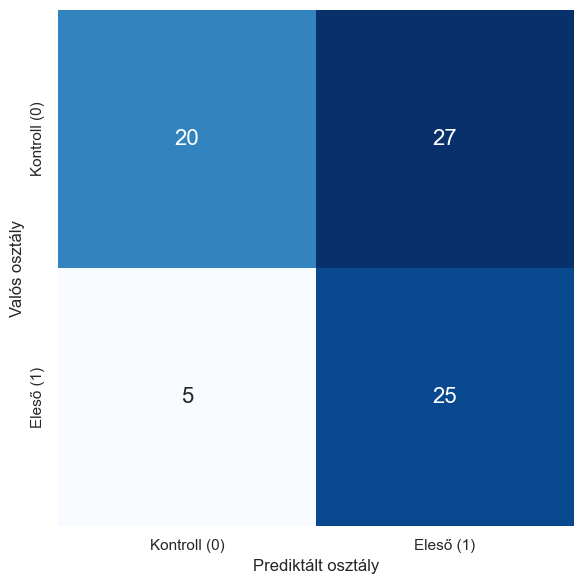

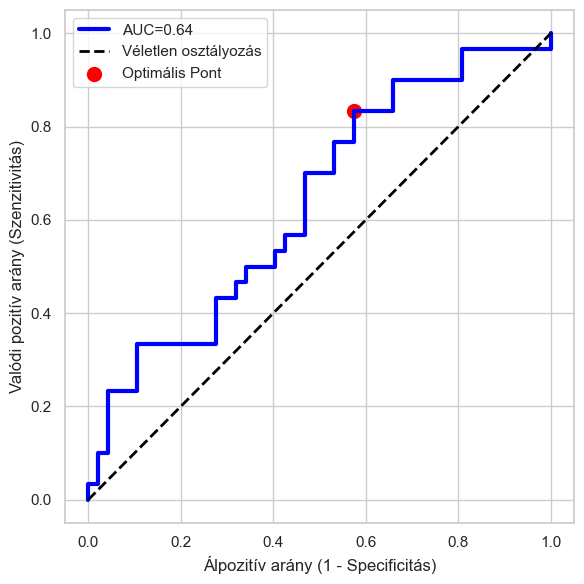

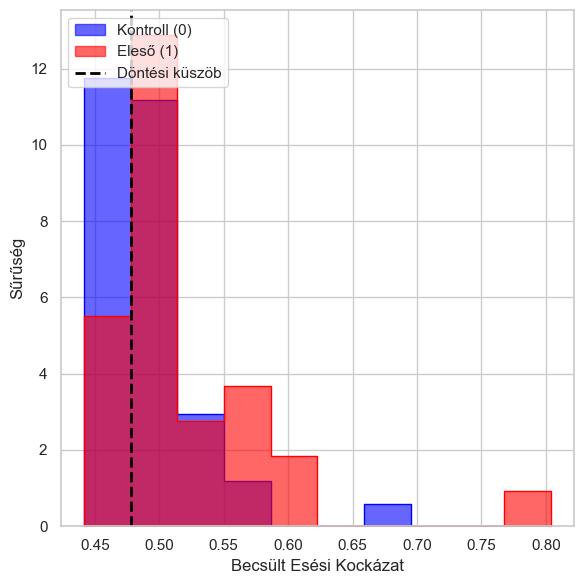

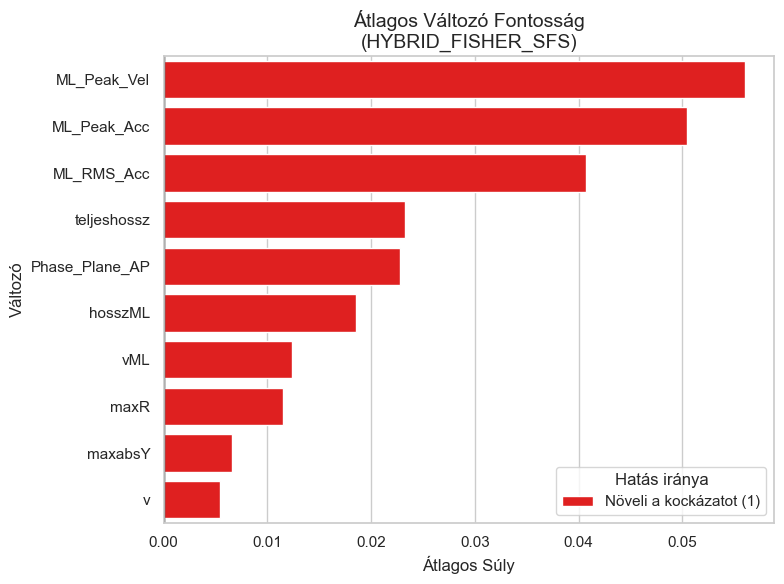

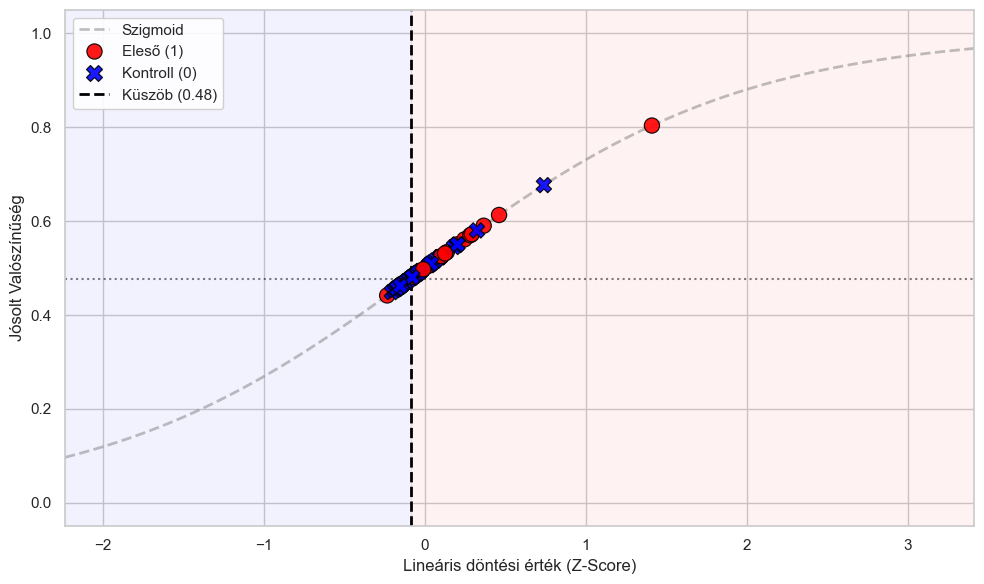

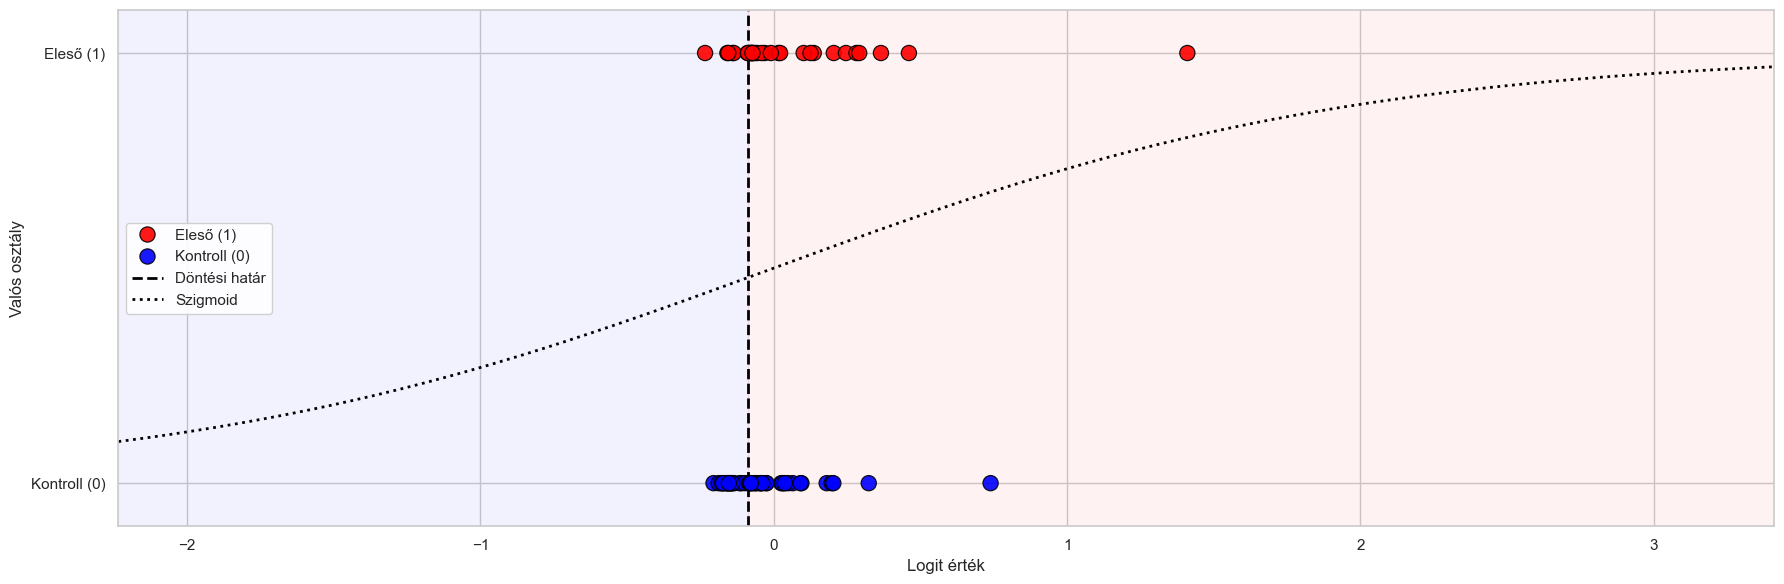

In [ ]:
# ==============================================================================
# KONFIGURÁCIÓ
# ==============================================================================
LOGREG_MODE = FEATURE_SELECTION_METHOD

THRESHOLD_MODE = "OPTIMAL" 
CUSTOM_VAL = 0.40

# 1. Reducer lekérése
current_reducer = get_reducer(LOGREG_MODE)

# 2. Modell definíció
clf_logreg = LogisticRegression(penalty='l2', solver='liblinear', C=0.01, 
                                class_weight='balanced', random_state=42)

# 3. Pipeline építése
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('reducer', current_reducer),
    ('classifier', clf_logreg)
])

# ==============================================================================
# LOOCV
# ==============================================================================
loo = LeaveOneOut()
y_true, y_probs, y_z_scores = [], [], []
coef_series_list = [] 

for train_idx, test_idx in loo.split(X_input):
    X_train, X_test = X_input.iloc[train_idx], X_input.iloc[test_idx]
    y_train, y_test = y_input.iloc[train_idx], y_input.iloc[test_idx]
    
    pipe_lr.fit(X_train, y_train)
    
    try:
        prob = pipe_lr.predict_proba(X_test)[0, 1]
        z_score = pipe_lr.decision_function(X_test)[0]
    except IndexError:
        prob = 0.0
        z_score = 0.0
        
    y_true.append(y_test.values[0])
    y_probs.append(prob)
    y_z_scores.append(z_score)
    
    # Együtthatók mentése az elemzéshez
    try:
        if hasattr(pipe_lr.named_steps['classifier'], 'coef_'):
            coefs = pipe_lr.named_steps['classifier'].coef_[0]
            if hasattr(pipe_lr.named_steps['reducer'], 'get_feature_names_out'):
                feat_names = pipe_lr.named_steps['reducer'].get_feature_names_out(X_input.columns)
            else:
                feat_names = [f"Comp_{i}" for i in range(len(coefs))]

            if len(coefs) == len(feat_names):
                coef_series_list.append(pd.Series(coefs, index=feat_names))
    except Exception:
        pass

# ==============================================================================
# KÜSZÖB SZÁMÍTÁSA
# ==============================================================================
fpr, tpr, thresholds = roc_curve(y_true, y_probs)

if THRESHOLD_MODE == "OPTIMAL":
    J = tpr - fpr
    ix = np.argmax(J)
    final_threshold = thresholds[ix]
    print(f"\n>> OPTIMÁLIS KÜSZÖB: {final_threshold:.4f}")
    
elif THRESHOLD_MODE == "FIXED":
    final_threshold = CUSTOM_VAL
    print(f"\n>> MANUÁLIS BEÁLLÍTÁS: {final_threshold:.4f}")
else:
    final_threshold = 0.5
    print(f"\n>> DEFAULT MÓD: Küszöb = 0.5")

# Tanulási pontosság a teljes halmazon
pipe_lr.fit(X_input, y_input)
y_train_probs = pipe_lr.predict_proba(X_input)[:, 1]
y_train_pred = [1 if p >= final_threshold else 0 for p in y_train_probs]
train_acc = accuracy_score(y_input, y_train_pred)

# ==============================================================================
# KIÉRTÉKELÉS
# ==============================================================================
y_pred = [1 if p >= final_threshold else 0 for p in y_probs]

test_acc = accuracy_score(y_true, y_pred)
roc_auc = auc(fpr, tpr)
mcc = matthews_corrcoef(y_true, y_pred)
sens = recall_score(y_true, y_pred, pos_label=1)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
spec = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = f1_score(y_true, y_pred)

print(f"Tanulási Pont.:  {train_acc:.1%}")
print(f"Teszt Pontosság: {test_acc:.1%}")
print(f"AUC érték:       {roc_auc:.4f}")
print(f"F1-érték:        {f1:.4f}")
print(f"Szenzitivitás:   {sens:.1%}")
print(f"Specificitás:    {spec:.1%}")
print(f"MCC:             {mcc:.4f}")

# ==============================================================================
# VIZUALIZÁCIÓ
# ==============================================================================
sns.set(style="whitegrid")
labels = ['Kontroll (0)', 'Eleső (1)']

# KONFÚZIÓS MÁTRIX
plt.figure(figsize=(6, 6))
sns.heatmap(confusion_matrix(y_true, y_pred), 
            annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Prediktált osztály')
plt.ylabel('Valós osztály')
plt.tight_layout()
plt.show()

# ROC GÖRBE
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=3, label=f'AUC={roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', lw=2, label='Véletlen osztályozás')
if THRESHOLD_MODE == "OPTIMAL":
    plt.scatter(fpr[ix], tpr[ix], marker='o', color='red', s=100, label='Optimális Pont')
plt.legend()
plt.tight_layout()
plt.show()

# VALÓSZÍNŰSÉG ELOSZLÁS
plt.figure(figsize=(6, 6))
plot_data = pd.DataFrame({'Prob': y_probs, 'True': y_true})
plot_data['True'] = plot_data['True'].map({0: 'Kontroll (0)', 1: 'Eleső (1)'})

ax = sns.histplot(data=plot_data, x='Prob', hue='True', 
                  element="step", stat="density", common_norm=False, 
                  palette={'Kontroll (0)': 'blue', 'Eleső (1)': 'red'},
                  bins=10, alpha=0.6, legend=False)

plt.axvline(final_threshold, color='black', linestyle='--', linewidth=2)

blue_patch = mpatches.Patch(color='blue', alpha=0.6, label='Kontroll (0)')
red_patch = mpatches.Patch(color='red', alpha=0.6, label='Eleső (1)')
threshold_line = Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Döntési küszöb')

plt.legend(handles=[blue_patch, red_patch, threshold_line], loc='upper left', frameon=True)

plt.xlabel('Becsült Esési Kockázat')
plt.ylabel('Sűrűség')
plt.tight_layout()
plt.show()

# VÁLTOZÓFONTOSSÁG
plt.figure(figsize=(8, 6))
if len(coef_series_list) > 0:
    coef_df_concat = pd.concat(coef_series_list, axis=1).fillna(0)
    avg_coefs = coef_df_concat.mean(axis=1)
    importance_df = pd.DataFrame({'Változó': avg_coefs.index, 'Együttható': avg_coefs.values})
    importance_df['Abs_Val'] = importance_df['Együttható'].abs()
    importance_df['Hatás'] = ['Növeli a kockázatot (1)' if x > 0 else 'Csökkenti a kockázatot (0)' for x in importance_df['Együttható']]
    importance_df_to_plot = importance_df.sort_values(by='Abs_Val', ascending=False).head(10)
    importance_df_to_plot['Változó'] = importance_df_to_plot['Változó'].astype(str).str.replace('Labfej', 'Lábfej', regex=False)

    sns.barplot(x='Együttható', y='Változó', data=importance_df_to_plot, hue='Hatás', dodge=False,
                palette={'Növeli a kockázatot (1)': 'red', 'Csökkenti a kockázatot (0)': 'blue'})
    plt.xlabel('Átlagos Súly')
    plt.axvline(0, color='black', linewidth=1)
    plt.legend(title='Hatás iránya')
plt.tight_layout()
plt.show()

# SZIGMOID GÖRBE ÉS VALÓS OSZTÁLYOK
plt.figure(figsize=(10, 6))
from scipy.special import expit

plot_df = pd.DataFrame({
    'Z_Score': y_z_scores,
    'Probability': y_probs,
    'Csoport': ['Eleső (1)' if y == 1 else 'Kontroll (0)' for y in y_true]
})

x_range = np.linspace(min(y_z_scores)-2, max(y_z_scores)+2, 500)
y_sigmoid = expit(x_range)
plt.plot(x_range, y_sigmoid, color='gray', linestyle='--', linewidth=2, alpha=0.5, label='Szigmoid')

sns.scatterplot(data=plot_df, x='Z_Score', y='Probability', hue='Csoport',
                palette={'Eleső (1)': 'red', 'Kontroll (0)': 'blue'}, 
                s=120, edgecolor='black', alpha=0.9, zorder=10)

if 0.001 < final_threshold < 0.999:
    z_thresh = -math.log(1/final_threshold - 1)
    plt.axvline(z_thresh, color='black', linestyle='--', linewidth=2, label='Döntési küszöb')
    plt.axvspan(z_thresh, max(x_range), color='red', alpha=0.05)
    plt.axvspan(min(x_range), z_thresh, color='blue', alpha=0.05)

plt.xlabel('Lineáris döntési érték (Z-Score)')
plt.ylabel('Becsült valószínűség')
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

## Előzetesen metszett döntési fa


>> MAXIMÁLIS MÉLYSÉG: 2.0000

>> OPTIMÁLIS KÜSZÖB: 0.2276
Tanulási Pont.:  68.8%
Teszt Pontosság: 63.6%
AUC érték:       0.5702
F1-érték:        0.6667
Szenzitivitás:   93.3%
Specificitás:    44.7%
MCC:             0.4050


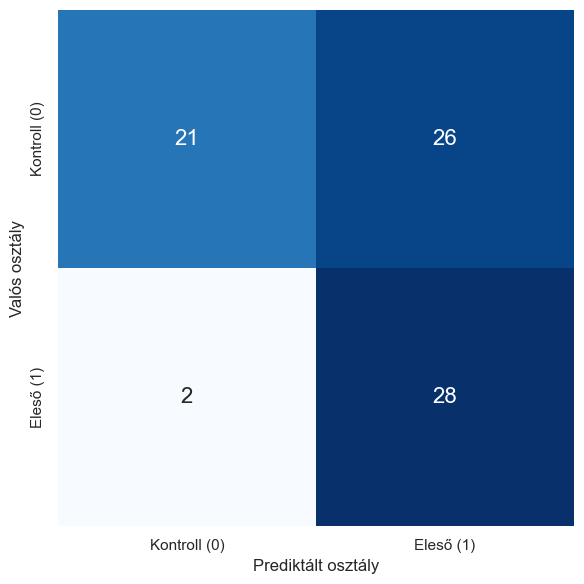

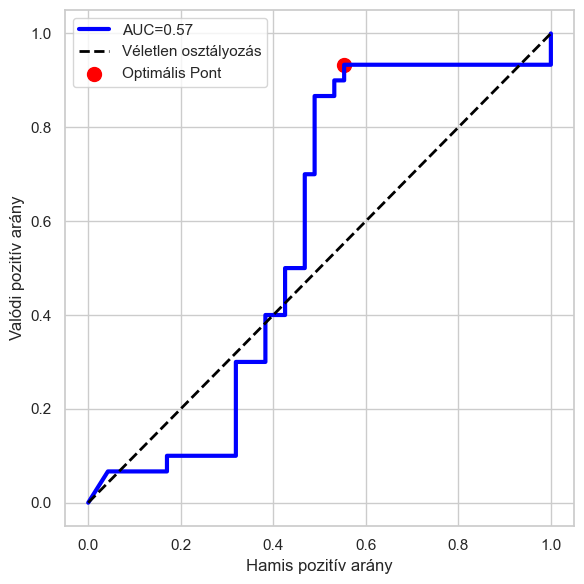

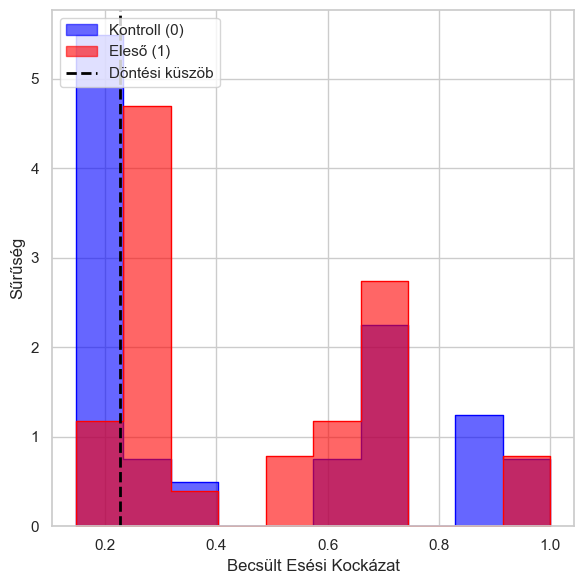

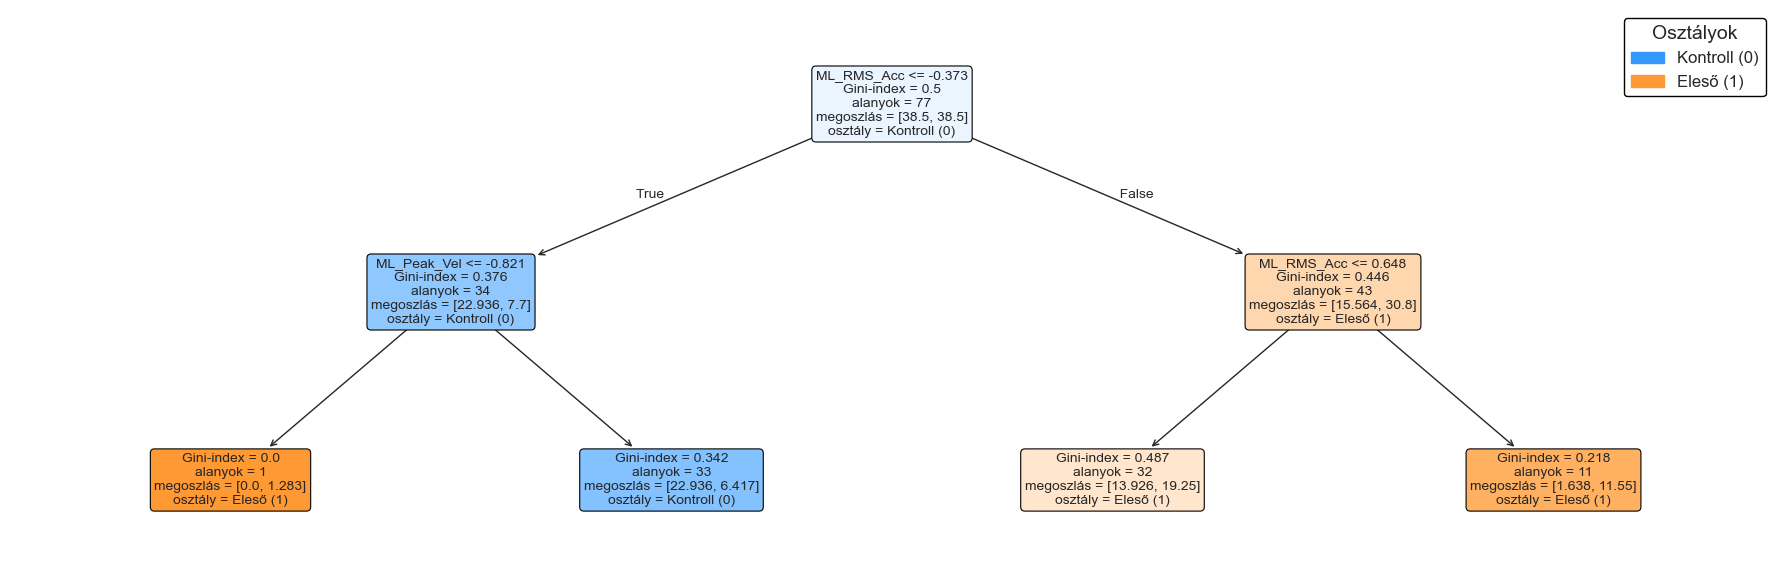

In [101]:
# ==============================================================================
# KONFIGURÁCIÓ
# ==============================================================================
TREE_MODE = FEATURE_SELECTION_METHOD 

THRESHOLD_MODE = "OPTIMAL" 
CUSTOM_VAL = 0.40
maximum_depth=2

current_reducer = get_reducer(TREE_MODE)

pipe_tree = Pipeline([
    ('scaler', StandardScaler()),
    ('reducer', current_reducer),
    ('classifier', DecisionTreeClassifier(max_depth=maximum_depth, class_weight='balanced', random_state=42))
])

print(f"\n>> MAXIMÁLIS MÉLYSÉG: {maximum_depth:.4f}")

# ==============================================================================
# LOOCV
# ==============================================================================
loo = LeaveOneOut()
y_true, y_probs = [], []

for train_idx, test_idx in loo.split(X_input):
    X_train, X_test = X_input.iloc[train_idx], X_input.iloc[test_idx]
    y_train, y_test = y_input.iloc[train_idx], y_input.iloc[test_idx]
    
    pipe_tree.fit(X_train, y_train)
    
    try:
        prob = pipe_tree.predict_proba(X_test)[0, 1]
    except IndexError:
        prob = 0.0
    
    y_true.append(y_test.values[0])
    y_probs.append(prob)

# Tanulási pontosság a teljes halmazon
pipe_tree.fit(X_input, y_input)
y_train_pred = pipe_tree.predict(X_input)
train_acc = accuracy_score(y_input, y_train_pred)

# ==============================================================================
# KÜSZÖB SZÁMÍTÁSA
# ==============================================================================
fpr, tpr, thresholds = roc_curve(y_true, y_probs)

if THRESHOLD_MODE == "OPTIMAL":
    J = tpr - fpr
    ix = np.argmax(J)
    final_threshold = thresholds[ix]
    print(f"\n>> OPTIMÁLIS KÜSZÖB: {final_threshold:.4f}")
    
elif THRESHOLD_MODE == "FIXED":
    final_threshold = CUSTOM_VAL
    print(f"\n>> MANUÁLIS BEÁLLÍTÁS: {final_threshold:.4f}")
else:
    final_threshold = 0.5
    print(f"\n>> DEFAULT MÓD: Küszöb = 0.5")

# ==============================================================================
# KIÉRTÉKELÉS
# ==============================================================================
y_pred = [1 if p >= final_threshold else 0 for p in y_probs]

test_acc = accuracy_score(y_true, y_pred)
roc_auc = auc(fpr, tpr)
mcc = matthews_corrcoef(y_true, y_pred)
sens = recall_score(y_true, y_pred, pos_label=1)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
spec = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = f1_score(y_true, y_pred)

print(f"Tanulási Pont.:  {train_acc:.1%}")
print(f"Teszt Pontosság: {test_acc:.1%}")
print(f"AUC érték:       {roc_auc:.4f}")
print(f"F1-érték:        {f1:.4f}")
print(f"Szenzitivitás:   {sens:.1%}")
print(f"Specificitás:    {spec:.1%}")
print(f"MCC:             {mcc:.4f}")

# ==============================================================================
# VIZUALIZÁCIÓ
# ==============================================================================
import re
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from sklearn.tree import plot_tree
import matplotlib.colors as mcolors

sns.set(style="whitegrid")
labels = ['Kontroll (0)', 'Eleső (1)']

# KONFÚZIÓS MÁTRIX
plt.figure(figsize=(6, 6))
sns.heatmap(confusion_matrix(y_true, y_pred), 
            annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={"size": 16},
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Prediktált osztály')
plt.ylabel('Valós osztály')
plt.tight_layout()
plt.show()

# ROC GÖRBE
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=3, label=f'AUC={roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', lw=2, label='Véletlen osztályozás')
if THRESHOLD_MODE == "OPTIMAL":
    plt.scatter(fpr[ix], tpr[ix], marker='o', color='red', s=100, label='Optimális Pont')
plt.xlabel('Hamis pozitív arány')
plt.ylabel('Valódi pozitív arány')
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# VALÓSZÍNŰSÉG ELOSZLÁS
plt.figure(figsize=(6, 6))
plot_data = pd.DataFrame({'Prob': y_probs, 'True': y_true})
plot_data['True'] = plot_data['True'].map({0: 'Kontroll (0)', 1: 'Eleső (1)'})

ax = sns.histplot(data=plot_data, x='Prob', hue='True', 
                  element="step", stat="density", common_norm=False, 
                  palette={'Kontroll (0)': 'blue', 'Eleső (1)': 'red'},
                  bins=10, alpha=0.6, legend=False)

plt.axvline(final_threshold, color='black', linestyle='--', linewidth=2)

blue_patch = mpatches.Patch(color='blue', alpha=0.6, label='Kontroll (0)')
red_patch = mpatches.Patch(color='red', alpha=0.6, label='Eleső (1)')
threshold_line = Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Döntési küszöb')

plt.legend(handles=[blue_patch, red_patch, threshold_line], loc='upper left', frameon=True)
plt.xlabel('Becsült Esési Kockázat')
plt.ylabel('Sűrűség')
plt.tight_layout()
plt.show()

# ==============================================================================
# DÖNTÉSI FA ÁBRÁZOLÁSA
# ==============================================================================
plt.figure(figsize=(18, 6))

final_tree_model = pipe_tree.named_steps['classifier']
reducer_step = pipe_tree.named_steps['reducer']
feature_names = None

try:
    feature_names = list(pipe_tree[:-1].get_feature_names_out(X_input.columns))
except Exception:
    if hasattr(reducer_step, 'get_support'):
        support = reducer_step.get_support()
        feature_names = list(X_input.columns[support])
    else:
        n_features = final_tree_model.n_features_in_
        feature_names = [f"Feat_{i}" for i in range(n_features)]

clean_feature_names = []
for name in feature_names:
    if re.search(r'(Feat_|x\d+)', name, re.IGNORECASE):
        nums = re.findall(r'\d+', name)
        if nums:
            idx = int(nums[-1])
            if idx < len(X_input.columns):
                clean_feature_names.append(X_input.columns[idx])
                continue
    clean_feature_names.append(name)
feature_names = clean_feature_names

annotations = plot_tree(final_tree_model, 
                        filled=True, 
                        feature_names=feature_names, 
                        class_names=['Kontroll (0)', 'Eleső (1)'], 
                        rounded=True, 
                        fontsize=10)

for ann in annotations:
    txt = ann.get_text()
    bbox = ann.get_bbox_patch()
    
    if bbox is not None:
        p_max = 0.5
        v_match = re.search(r'value = \[([^\]]+)\]', txt)
        if v_match:
            try:
                vals = [float(x.strip()) for x in v_match.group(1).split(',')]
                total = sum(vals)
                if total > 0:
                    p_max = max(vals) / total
            except ValueError:
                pass

        alpha = (p_max - 0.5) / 0.5
        alpha = 0.1 + (0.9 * alpha) 

        white = np.array([1.0, 1.0, 1.0])
        blue_base = np.array([0.2, 0.6, 1.0])
        orange_base = np.array([1.0, 0.6, 0.2])

        if "Eleső (1)" in txt:
            new_color = (1 - alpha) * white + alpha * orange_base
        elif "Kontroll (0)" in txt:
            new_color = (1 - alpha) * white + alpha * blue_base
        else:
            new_color = white

        bbox.set_facecolor(new_color)
        bbox.set_edgecolor('black')
        bbox.set_linewidth(0.8)

    new_txt = txt.replace('samples', 'alanyok')
    new_txt = new_txt.replace('value', 'megoszlás')
    new_txt = new_txt.replace('class', 'osztály')
    new_txt = new_txt.replace('gini', 'Gini-index')
    ann.set_text(new_txt)

control_patch = mpatches.Patch(color=[0.2, 0.6, 1.0], label='Kontroll (0)')
faller_patch = mpatches.Patch(color=[1.0, 0.6, 0.2], label='Eleső (1)')

plt.legend(handles=[control_patch, faller_patch], 
           loc='upper right', 
           fontsize=12, 
           title='Osztályok', 
           title_fontsize=14, 
           framealpha=1.0, 
           edgecolor='black')

plt.tight_layout()
plt.show()

## Utólagosan metszett döntési fa


>> OPTIMÁLIS KÜSZÖB: 0.3002
Tanulási Pont.:  67.5%
Teszt Pontosság: 63.6%
AUC érték:       0.5887
F1-érték:        0.6410
Szenzitivitás:   83.3%
Specificitás:    51.1%
MCC:             0.3462


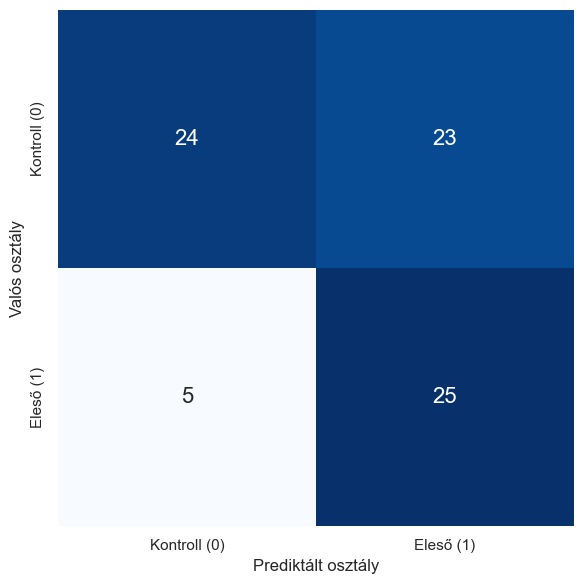

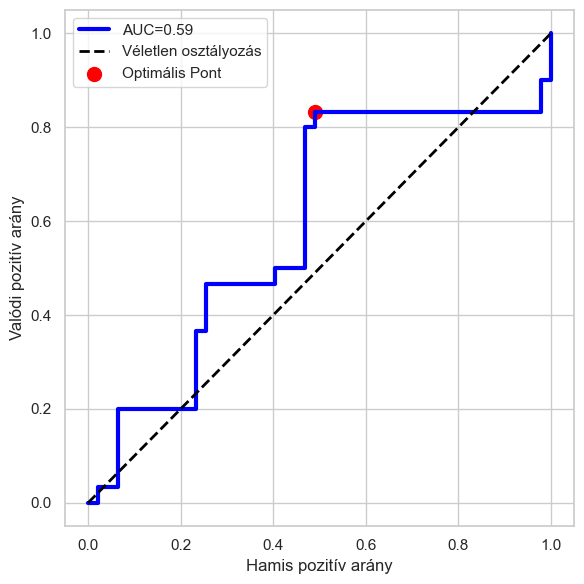

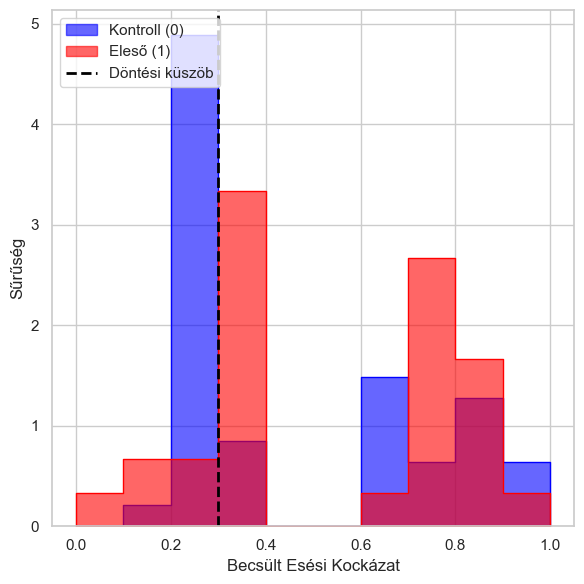

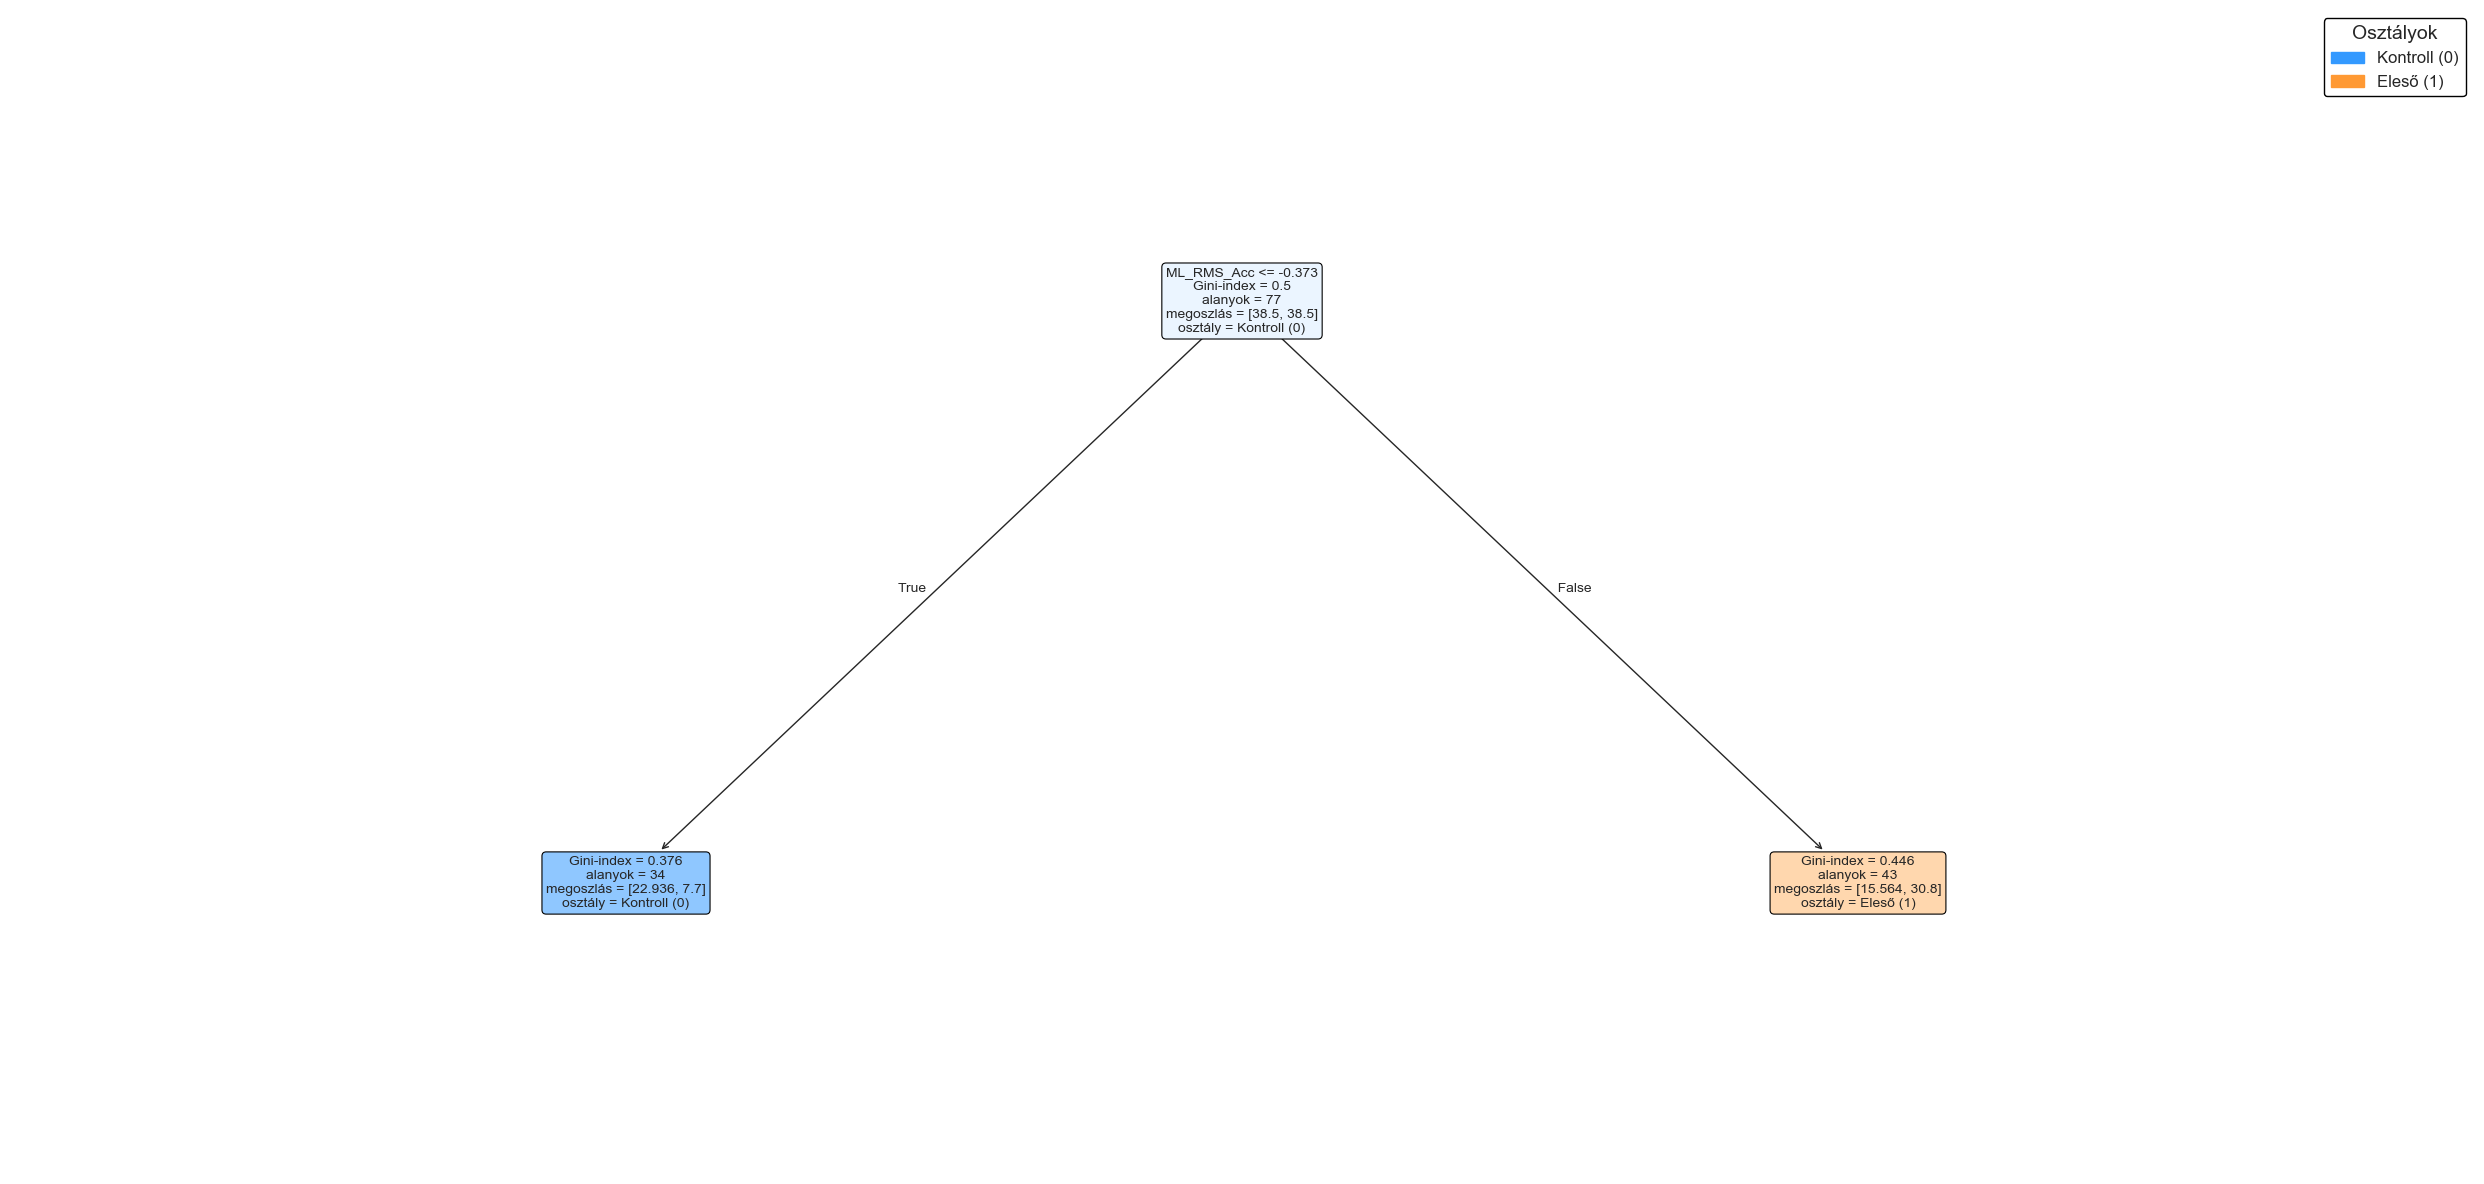

In [100]:
# ==============================================================================
# KONFIGURÁCIÓ
# ==============================================================================
PRUNED_TREE_MODE = FEATURE_SELECTION_METHOD

# NYESÉS BEÁLLÍTÁSA
USE_MANUAL_ALPHA = True 
MANUAL_ALPHA_VAL = 0.025

THRESHOLD_MODE = "OPTIMAL"
CUSTOM_VAL = 0.6

# 1. Reducer sablon
reducer_template = get_reducer(PRUNED_TREE_MODE)

# ==============================================================================
# LOOCV
# ==============================================================================
loo = LeaveOneOut()
y_true, y_probs, best_alphas = [], [], []

for train_idx, test_idx in loo.split(X_input):
    X_train, X_test = X_input.iloc[train_idx], X_input.iloc[test_idx]
    y_train, y_test = y_input.iloc[train_idx], y_input.iloc[test_idx]
    
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    if reducer_template != 'passthrough':
        red = clone(reducer_template)
        X_train_r = red.fit_transform(X_train_s, y_train)
        X_test_r = red.transform(X_test_s)
    else:
        X_train_r, X_test_r = X_train_s, X_test_s

    if USE_MANUAL_ALPHA:
        # Manuális nyesés alkalmazása
        best_clf = DecisionTreeClassifier(ccp_alpha=MANUAL_ALPHA_VAL, 
                                          class_weight='balanced', 
                                          random_state=42,
                                          min_samples_leaf=5)
        best_clf.fit(X_train_r, y_train)
        best_alphas.append(MANUAL_ALPHA_VAL)
    else:
        # Automatikus nyesési út keresése
        dt_temp = DecisionTreeClassifier(random_state=42, class_weight='balanced')
        path = dt_temp.cost_complexity_pruning_path(X_train_r, y_train)
        ccp_alphas = path.ccp_alphas[:-1]
        
        gs = GridSearchCV(
            DecisionTreeClassifier(random_state=42, class_weight='balanced'),
            param_grid={'ccp_alpha': ccp_alphas},
            cv=3, scoring='matthews_corrcoef', n_jobs=-1
        )
        gs.fit(X_train_r, y_train)
        best_clf = gs.best_estimator_
        best_alphas.append(gs.best_params_['ccp_alpha'])
    
    try:
        prob = best_clf.predict_proba(X_test_r)[0, 1]
    except:
        prob = 0.0
    y_true.append(y_test.values[0])
    y_probs.append(prob)

# Tanulási pontosság a teljes halmazon
avg_alpha = np.mean(best_alphas)
final_tree_clf = DecisionTreeClassifier(ccp_alpha=avg_alpha, class_weight='balanced', random_state=42)

if reducer_template != 'passthrough':
    final_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('reducer', clone(reducer_template)),
        ('classifier', final_tree_clf)
    ])
else:
    final_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', final_tree_clf)
    ])

final_pipe.fit(X_input, y_input)
y_train_pred = final_pipe.predict(X_input)
train_acc = accuracy_score(y_input, y_train_pred)

# ==============================================================================
# KÜSZÖB SZÁMÍTÁSA
# ==============================================================================
fpr, tpr, thresholds = roc_curve(y_true, y_probs)

if THRESHOLD_MODE == "OPTIMAL":
    J = tpr - fpr
    ix = np.argmax(J)
    final_threshold = thresholds[ix]
    print(f"\n>> OPTIMÁLIS KÜSZÖB: {final_threshold:.4f}")
    
elif THRESHOLD_MODE == "FIXED":
    final_threshold = CUSTOM_VAL
    print(f"\n>> MANUÁLIS BEÁLLÍTÁS: {final_threshold:.4f}")
else:
    final_threshold = 0.5
    print(f"\n>> DEFAULT MÓD: Küszöb = 0.5")

# ==============================================================================
# KIÉRTÉKELÉS
# ==============================================================================
y_pred = [1 if p >= final_threshold else 0 for p in y_probs]

test_acc = accuracy_score(y_true, y_pred)
roc_auc = auc(fpr, tpr)
mcc = matthews_corrcoef(y_true, y_pred)
sens = recall_score(y_true, y_pred, pos_label=1)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
spec = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = f1_score(y_true, y_pred)

print(f"Tanulási Pont.:  {train_acc:.1%}")
print(f"Teszt Pontosság: {test_acc:.1%}")
print(f"AUC érték:       {roc_auc:.4f}")
print(f"F1-érték:        {f1:.4f}")
print(f"Szenzitivitás:   {sens:.1%}")
print(f"Specificitás:    {spec:.1%}")
print(f"MCC:             {mcc:.4f}")

# ==============================================================================
# VIZUALIZÁCIÓ
# ==============================================================================
import re
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from sklearn.tree import plot_tree

sns.set(style="whitegrid")
labels = ['Kontroll (0)', 'Eleső (1)']

# KONFÚZIÓS MÁTRIX
plt.figure(figsize=(6, 6))
sns.heatmap(confusion_matrix(y_true, y_pred), 
            annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={"size": 16},
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Prediktált osztály')
plt.ylabel('Valós osztály')
plt.tight_layout()
plt.show()

# ROC GÖRBE
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=3, label=f'AUC={roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', lw=2, label='Véletlen osztályozás')
if THRESHOLD_MODE == "OPTIMAL":
    plt.scatter(fpr[ix], tpr[ix], marker='o', color='red', s=100, label='Optimális Pont')
plt.xlabel('Hamis pozitív arány')
plt.ylabel('Valódi pozitív arány')
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# VALÓSZÍNŰSÉG ELOSZLÁS
plt.figure(figsize=(6, 6))
plot_data = pd.DataFrame({'Prob': y_probs, 'True': y_true})
plot_data['True'] = plot_data['True'].map({0: 'Kontroll (0)', 1: 'Eleső (1)'})

ax = sns.histplot(data=plot_data, x='Prob', hue='True', 
                  element="step", stat="density", common_norm=False, 
                  palette={'Kontroll (0)': 'blue', 'Eleső (1)': 'red'},
                  bins=10, alpha=0.6, legend=False)

plt.axvline(final_threshold, color='black', linestyle='--', linewidth=2)

blue_patch = mpatches.Patch(color='blue', alpha=0.6, label='Kontroll (0)')
red_patch = mpatches.Patch(color='red', alpha=0.6, label='Eleső (1)')
threshold_line = Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Döntési küszöb')

plt.legend(handles=[blue_patch, red_patch, threshold_line], loc='upper left', frameon=True)
plt.xlabel('Becsült Esési Kockázat')
plt.ylabel('Sűrűség')
plt.tight_layout()
plt.show()

# ==============================================================================
# DÖNTÉSI FA ÁBRÁZOLÁSA
# ==============================================================================
plt.figure(figsize=(25, 12))

final_tree_model = final_pipe.named_steps['classifier']
try:
    reducer_step = final_pipe.named_steps['reducer']
except KeyError:
    reducer_step = None

feature_names = None

# Változónevek kinyerése
try:
    feature_names = list(final_pipe[:-1].get_feature_names_out(X_input.columns))
except Exception:
    if reducer_step and hasattr(reducer_step, 'get_support'):
        support = reducer_step.get_support()
        feature_names = list(X_input.columns[support])
    else:
        n_features = final_tree_model.n_features_in_
        feature_names = [f"Feat_{i}" for i in range(n_features)]

clean_feature_names = []
for name in feature_names:
    if re.search(r'(Feat_|x\d+)', name, re.IGNORECASE):
        nums = re.findall(r'\d+', name)
        if nums:
            idx = int(nums[-1])
            if idx < len(X_input.columns):
                clean_feature_names.append(X_input.columns[idx])
                continue
    clean_feature_names.append(name)
feature_names = clean_feature_names

# Fa kirajzolása
annotations = plot_tree(final_tree_model, 
                        filled=True, 
                        feature_names=feature_names, 
                        class_names=['Kontroll (0)', 'Eleső (1)'], 
                        rounded=True, 
                        fontsize=10)

# Dinamikus színezés és magyarítás
for ann in annotations:
    txt = ann.get_text()
    bbox = ann.get_bbox_patch()
    
    if bbox is not None:
        p_max = 0.5
        v_match = re.search(r'value = \[([^\]]+)\]', txt)
        if v_match:
            try:
                vals = [float(x.strip()) for x in v_match.group(1).split(',')]
                total = sum(vals)
                if total > 0:
                    p_max = max(vals) / total
            except ValueError:
                pass

        alpha = (p_max - 0.5) / 0.5
        alpha = 0.1 + (0.9 * alpha) 

        white = np.array([1.0, 1.0, 1.0])
        blue_base = np.array([0.2, 0.6, 1.0])   # Kék a Kontrollhoz
        orange_base = np.array([1.0, 0.6, 0.2]) # Narancs az Elesőhöz

        if "Eleső (1)" in txt:
            new_color = (1 - alpha) * white + alpha * orange_base
        elif "Kontroll (0)" in txt:
            new_color = (1 - alpha) * white + alpha * blue_base
        else:
            new_color = white

        bbox.set_facecolor(new_color)
        bbox.set_edgecolor('black')
        bbox.set_linewidth(0.8)

    # Szöveg magyarítása
    new_txt = txt.replace('samples', 'alanyok')
    new_txt = new_txt.replace('value', 'megoszlás')
    new_txt = new_txt.replace('class', 'osztály')
    new_txt = new_txt.replace('gini', 'Gini-index')
    ann.set_text(new_txt)

# Jelmagyarázat hozzáadása
control_patch = mpatches.Patch(color=[0.2, 0.6, 1.0], label='Kontroll (0)')
faller_patch = mpatches.Patch(color=[1.0, 0.6, 0.2], label='Eleső (1)')

plt.legend(handles=[control_patch, faller_patch], 
           loc='upper right', 
           fontsize=12, 
           title='Osztályok', 
           title_fontsize=14, 
           framealpha=1.0, 
           edgecolor='black')

plt.tight_layout()
plt.show()

## Random forest


>> OPTIMÁLIS HIPERPARAMÉTEREK: n_estimators=500, max_depth=1, max_features=sqrt

>> OPTIMÁLIS KÜSZÖB: 0.3940
Tanulási Pont.:  70.1%
Teszt Pontosság: 62.3%
AUC érték:       0.5957
F1-érték:        0.6133
Szenzitivitás:   76.7%
Specificitás:    53.2%
MCC:             0.2955


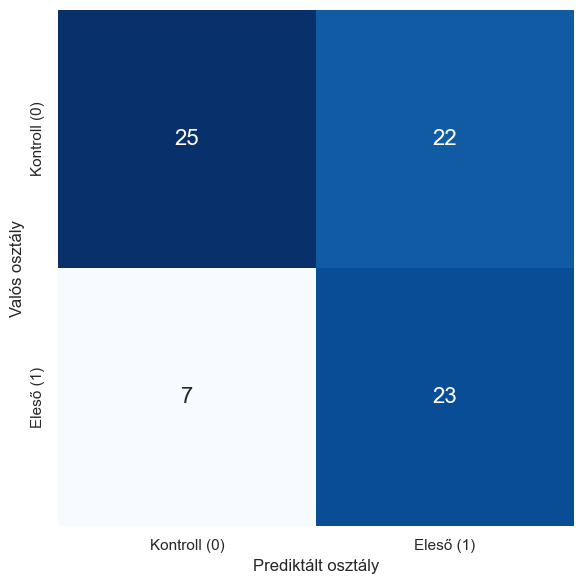

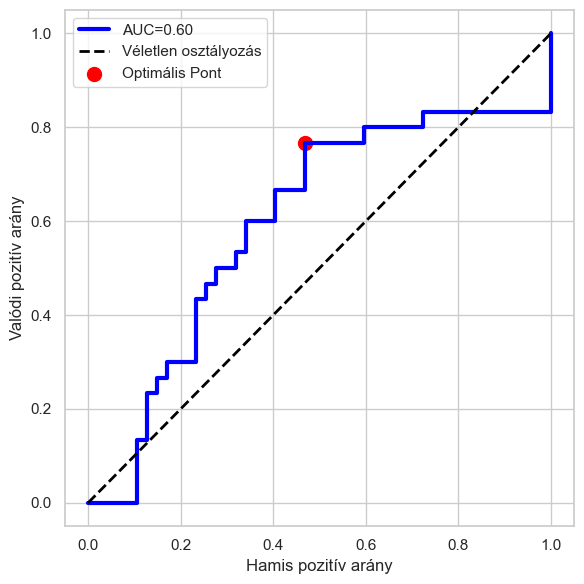

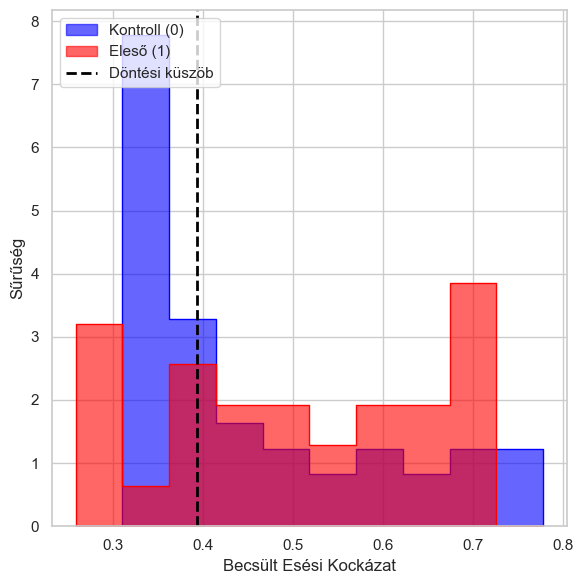

C:\Users\gerge\AppData\Local\Temp\ipykernel_22228\2279537208.py:201: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Fontosság', y='Változó', data=fi_df, palette='Blues_r')


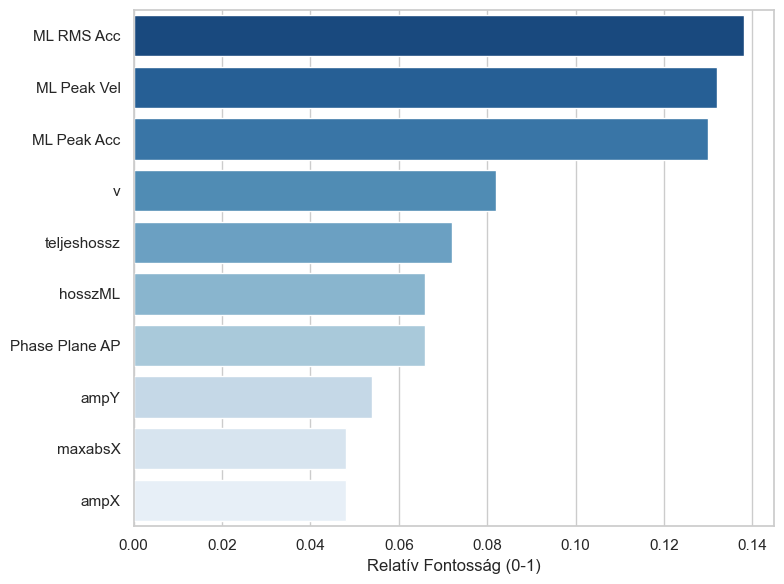

In [102]:
# ==============================================================================
# KONFIGURÁCIÓ
# ==============================================================================
RF_MODE = 'HYBRID_ENSEMBLE'
THRESHOLD_MODE = "OPTIMAL" 
CUSTOM_VAL = 0.45

# 1. Reducer lekérése
current_reducer = get_reducer(RF_MODE)

# 2. Pipeline építése
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('reducer', current_reducer),
    ('classifier', RandomForestClassifier(
        n_estimators=100,       
        max_depth=4,            
        max_features=None,      
        min_samples_leaf=20,    
        min_samples_split=20,   
        class_weight='balanced',
        random_state=42
    ))
])

# ==============================================================================
# RANDOM FOREST HYPERPARAMÉTER OPTIMALIZÁLÁS (GRID SEARCH)
# ==============================================================================
OPTIMIZATION_METRIC = 'roc_auc' 

# 1. Alap pipeline definiálása a kereséshez
pipe_base = Pipeline([
    ('scaler', StandardScaler()),
    ('reducer', current_reducer),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# 2. A keresési tér (Grid) meghatározása
param_grid = {
    'classifier__n_estimators': [500],  
    'classifier__max_depth': [1, 2, 3],
    'classifier__max_features': ['sqrt', 'log2', None]
}

# 3. Kereső modul beállítása
gs = GridSearchCV(
    estimator=pipe_base,
    param_grid=param_grid,
    scoring=OPTIMIZATION_METRIC,
    cv=5, 
    n_jobs=-1
)

# 4. Keresés lefuttatása
gs.fit(X_input, y_input)

# 5. Eredmények kiírása (A kért egyedi formátumban)
best_params = gs.best_params_
print(f"\n>> OPTIMÁLIS HIPERPARAMÉTEREK: n_estimators={best_params['classifier__n_estimators']}, max_depth={best_params['classifier__max_depth']}, max_features={best_params['classifier__max_features']}")

# 6. A végső modell mentése
pipe_rf = gs.best_estimator_

# ==============================================================================
# LOOCV
# ==============================================================================
loo = LeaveOneOut()
y_true, y_probs = [], []

for train_idx, test_idx in loo.split(X_input):
    X_train, X_test = X_input.iloc[train_idx], X_input.iloc[test_idx]
    y_train, y_test = y_input.iloc[train_idx], y_input.iloc[test_idx]
    
    pipe_rf.fit(X_train, y_train)
    
    try:
        model_classes = pipe_rf.named_steps['classifier'].classes_
        target_idx = np.where(model_classes == 1)[0][0]
        prob = pipe_rf.predict_proba(X_test)[0, target_idx]
    except:
        prob = 0.0
        
    y_true.append(y_test.values[0])
    y_probs.append(prob)

# Tanulási pontosság a teljes halmazon és változó fontosság kinyerése
pipe_rf.fit(X_input, y_input)
y_train_pred = pipe_rf.predict(X_input)
train_acc = accuracy_score(y_input, y_train_pred)

rf_model = pipe_rf.named_steps['classifier']
importances = rf_model.feature_importances_

if hasattr(pipe_rf.named_steps['reducer'], 'get_feature_names_out'):
    feature_names = pipe_rf.named_steps['reducer'].get_feature_names_out(X_input.columns)
else:
    feature_names = X_input.columns

# ==============================================================================
# KÜSZÖB SZÁMÍTÁSA
# ==============================================================================
fpr, tpr, thresholds = roc_curve(y_true, y_probs)

if THRESHOLD_MODE == "OPTIMAL":
    J = tpr - fpr
    ix = np.argmax(J)
    final_threshold = thresholds[ix]
    print(f"\n>> OPTIMÁLIS KÜSZÖB: {final_threshold:.4f}")
    
elif THRESHOLD_MODE == "FIXED":
    final_threshold = CUSTOM_VAL
    print(f"\n>> MANUÁLIS BEÁLLÍTÁS: {final_threshold:.4f}")
else:
    final_threshold = 0.5
    print(f"\n>> DEFAULT MÓD: Küszöb = 0.5")

# ==============================================================================
# KIÉRTÉKELÉS
# ==============================================================================
y_pred = [1 if p >= final_threshold else 0 for p in y_probs]

test_acc = accuracy_score(y_true, y_pred)
roc_auc = auc(fpr, tpr)
mcc = matthews_corrcoef(y_true, y_pred)
sens = recall_score(y_true, y_pred, pos_label=1)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
spec = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = f1_score(y_true, y_pred)

print(f"Tanulási Pont.:  {train_acc:.1%}")
print(f"Teszt Pontosság: {test_acc:.1%}")
print(f"AUC érték:       {roc_auc:.4f}")
print(f"F1-érték:        {f1:.4f}")
print(f"Szenzitivitás:   {sens:.1%}")
print(f"Specificitás:    {spec:.1%}")
print(f"MCC:             {mcc:.4f}")

# ==============================================================================
# VIZUALIZÁCIÓ
# ==============================================================================
import re
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

sns.set(style="whitegrid")
labels = ['Kontroll (0)', 'Eleső (1)']

# KONFÚZIÓS MÁTRIX
plt.figure(figsize=(6, 6))
sns.heatmap(confusion_matrix(y_true, y_pred), 
            annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={"size": 16},
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Prediktált osztály')
plt.ylabel('Valós osztály')
plt.tight_layout()
plt.show()

# ROC GÖRBE
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=3, label=f'AUC={roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', lw=2, label='Véletlen osztályozás')
if THRESHOLD_MODE == "OPTIMAL":
    plt.scatter(fpr[ix], tpr[ix], marker='o', color='red', s=100, label='Optimális Pont')
plt.xlabel('Hamis pozitív arány')
plt.ylabel('Valódi pozitív arány')
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# VALÓSZÍNŰSÉG ELOSZLÁS
plt.figure(figsize=(6, 6))
plot_data = pd.DataFrame({'Prob': y_probs, 'True': y_true})
plot_data['True'] = plot_data['True'].map({0: 'Kontroll (0)', 1: 'Eleső (1)'})

ax = sns.histplot(data=plot_data, x='Prob', hue='True', 
                  element="step", stat="density", common_norm=False, 
                  palette={'Kontroll (0)': 'blue', 'Eleső (1)': 'red'},
                  bins=10, alpha=0.6, legend=False)

plt.axvline(final_threshold, color='black', linestyle='--', linewidth=2)

blue_patch = mpatches.Patch(color='blue', alpha=0.6, label='Kontroll (0)')
red_patch = mpatches.Patch(color='red', alpha=0.6, label='Eleső (1)')
threshold_line = Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Döntési küszöb')

plt.legend(handles=[blue_patch, red_patch, threshold_line], loc='upper left', frameon=True)
plt.xlabel('Becsült Esési Kockázat')
plt.ylabel('Sűrűség')
plt.tight_layout()
plt.show()

# VÁLTOZÓ FONTOSSÁG
plt.figure(figsize=(8, 6))
fi_df = pd.DataFrame({'Változó': feature_names, 'Fontosság': importances})
fi_df = fi_df.sort_values(by='Fontosság', ascending=False).head(10)

fi_df['Változó'] = fi_df['Változó'].astype(str).str.replace('Labfej', 'Lábfej', regex=False)
fi_df['Változó'] = fi_df['Változó'].str.replace('_', ' ')

sns.barplot(x='Fontosság', y='Változó', data=fi_df, palette='Blues_r')
plt.xlabel('Relatív Fontosság (0-1)', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

## XGBoost


>> OPTIMÁLIS HIPERPARAMÉTEREK: n_estimators=100, max_depth=1, learning_rate=0.3, subsample=0.7, reg_alpha=5, reg_lambda=5

>> OPTIMÁLIS KÜSZÖB: 0.4611
Tanulási Pont.:  72.7%
Teszt Pontosság: 64.9%
AUC érték:       0.5674
F1-érték:        0.6197
Szenzitivitás:   73.3%
Specificitás:    59.6%
MCC:             0.3216


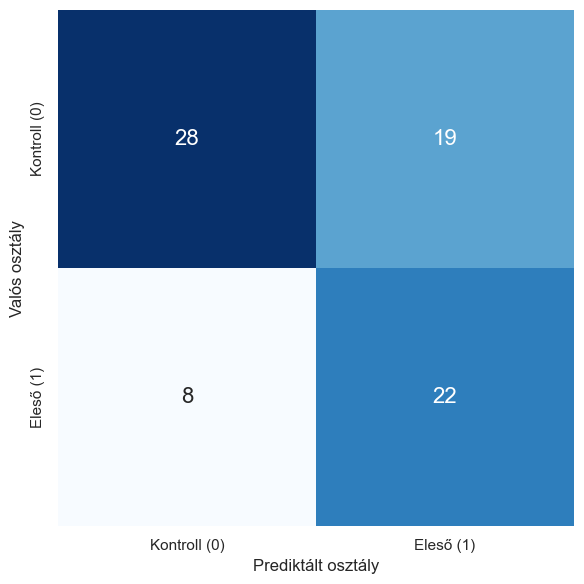

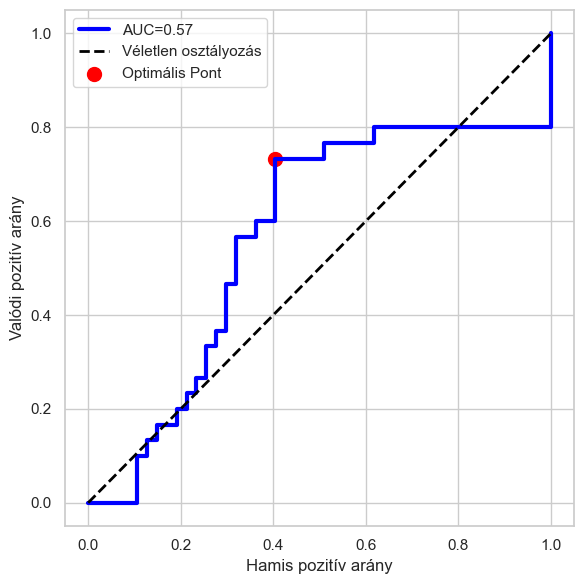

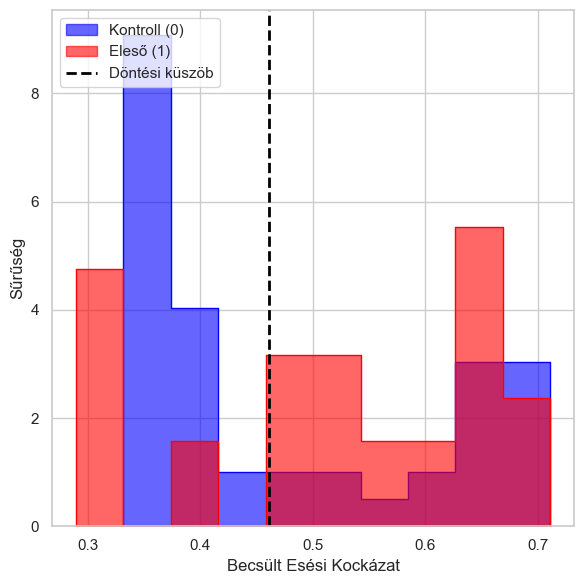

In [105]:
# ==============================================================================
# KONFIGURÁCIÓ
# ==============================================================================
XGB_MODE = 'HYBRID_ENSEMBLE' 
THRESHOLD_MODE = "OPTIMAL" 
CUSTOM_VAL = 0.45

# Osztályok arányának kiszámítása a súlyozáshoz
neg_count = len(y_input[y_input == 0])
pos_count = len(y_input[y_input == 1])
scale_weight = neg_count / pos_count if pos_count > 0 else 1.0

# 1. Reducer lekérése
current_reducer = get_reducer(XGB_MODE)

# 2. Pipeline építése
pipe_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('reducer', current_reducer),
    ('classifier', xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.02,
        max_depth=3,
        min_child_weight=5,
        gamma=0.5,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_lambda=2,
        scale_pos_weight=scale_weight,
        eval_metric='logloss',
        random_state=42
    ))
])

# ==============================================================================
# XGBOOST HYPERPARAMÉTER OPTIMALIZÁLÁS (GRID SEARCH)
# ==============================================================================
# 1. Alap pipeline a kereséshez
pipe_base = Pipeline([
    ('scaler', StandardScaler()),
    ('reducer', current_reducer),
    ('classifier', xgb.XGBClassifier(
        eval_metric='logloss',
        scale_pos_weight=scale_weight,
        random_state=42
    ))
])

# 2. Paraméter-rács meghatározása
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [1, 2, 3],
    'classifier__learning_rate': [0.3],
    'classifier__subsample': [0.7, 0.8],
    'classifier__colsample_bytree': [0.6, 0.7, 0.8],
    'classifier__reg_alpha': [0, 0.1, 1, 3, 5, 10],
    'classifier__reg_lambda': [0, 1, 3, 5, 10]
}

# 3. Kereső modul beállítása
gs_xgb = GridSearchCV(
    estimator=pipe_base,
    param_grid=param_grid,
    scoring='roc_auc', 
    cv=5, 
    n_jobs=-1
)

# 4. Keresés futtatása
gs_xgb.fit(X_input, y_input)

# 5. Eredmények kiírása (A kért egyedi formátumban)
best_params = gs_xgb.best_params_
print(f"\n>> OPTIMÁLIS HIPERPARAMÉTEREK: n_estimators={best_params['classifier__n_estimators']}, max_depth={best_params['classifier__max_depth']}, learning_rate={best_params['classifier__learning_rate']}, subsample={best_params['classifier__subsample']}, reg_alpha={best_params['classifier__reg_alpha']}, reg_lambda={best_params['classifier__reg_lambda']}")

# 6. A végső modell mentése
pipe_xgb = gs_xgb.best_estimator_

# ==============================================================================
# LOOCV
# ==============================================================================
loo = LeaveOneOut()
y_true, y_probs = [], []

for train_idx, test_idx in loo.split(X_input):
    X_train, X_test = X_input.iloc[train_idx], X_input.iloc[test_idx]
    y_train, y_test = y_input.iloc[train_idx], y_input.iloc[test_idx]
    
    pipe_xgb.fit(X_train, y_train)
    
    try:
        prob = pipe_xgb.predict_proba(X_test)[0, 1]
    except Exception:
        prob = 0.0
        
    y_true.append(y_test.values[0])
    y_probs.append(prob)

# Tanulási pontosság a teljes halmazon és változó fontosság kinyerése
pipe_xgb.fit(X_input, y_input) 
y_train_pred = pipe_xgb.predict(X_input)
train_acc = accuracy_score(y_input, y_train_pred)

xgb_model = pipe_xgb.named_steps['classifier']
importances = xgb_model.feature_importances_

if hasattr(pipe_xgb.named_steps['reducer'], 'get_feature_names_out'):
    feature_names = pipe_xgb.named_steps['reducer'].get_feature_names_out(X_input.columns)
else:
    feature_names = X_input.columns

# ==============================================================================
# KÜSZÖB SZÁMÍTÁSA
# ==============================================================================
fpr, tpr, thresholds = roc_curve(y_true, y_probs)

if THRESHOLD_MODE == "OPTIMAL":
    J = tpr - fpr
    ix = np.argmax(J)
    final_threshold = thresholds[ix]
    print(f"\n>> OPTIMÁLIS KÜSZÖB: {final_threshold:.4f}")
    
elif THRESHOLD_MODE == "FIXED":
    final_threshold = CUSTOM_VAL
    print(f"\n>> MANUÁLIS BEÁLLÍTÁS: {final_threshold:.4f}")
else:
    final_threshold = 0.5
    print(f"\n>> DEFAULT MÓD: Küszöb = 0.5")

# ==============================================================================
# KIÉRTÉKELÉS
# ==============================================================================
y_pred = [1 if p >= final_threshold else 0 for p in y_probs]

test_acc = accuracy_score(y_true, y_pred)
roc_auc = auc(fpr, tpr)
mcc = matthews_corrcoef(y_true, y_pred)
sens = recall_score(y_true, y_pred, pos_label=1)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
spec = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = f1_score(y_true, y_pred)

print(f"Tanulási Pont.:  {train_acc:.1%}")
print(f"Teszt Pontosság: {test_acc:.1%}")
print(f"AUC érték:       {roc_auc:.4f}")
print(f"F1-érték:        {f1:.4f}")
print(f"Szenzitivitás:   {sens:.1%}")
print(f"Specificitás:    {spec:.1%}")
print(f"MCC:             {mcc:.4f}")

# ==============================================================================
# VIZUALIZÁCIÓ
# ==============================================================================
sns.set(style="whitegrid")
labels = ['Kontroll (0)', 'Eleső (1)']

# KONFÚZIÓS MÁTRIX
plt.figure(figsize=(6, 6))
sns.heatmap(confusion_matrix(y_true, y_pred), 
            annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={"size": 16},
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Prediktált osztály')
plt.ylabel('Valós osztály')
plt.tight_layout()
plt.show()

# ROC GÖRBE
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=3, label=f'AUC={roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', lw=2, label='Véletlen osztályozás')
if THRESHOLD_MODE == "OPTIMAL":
    plt.scatter(fpr[ix], tpr[ix], marker='o', color='red', s=100, label='Optimális Pont')
plt.xlabel('Hamis pozitív arány')
plt.ylabel('Valódi pozitív arány')
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# VALÓSZÍNŰSÉG ELOSZLÁS
plt.figure(figsize=(6, 6))
plot_data = pd.DataFrame({'Prob': y_probs, 'True': y_true})
plot_data['True'] = plot_data['True'].map({0: 'Kontroll (0)', 1: 'Eleső (1)'})

ax = sns.histplot(data=plot_data, x='Prob', hue='True', 
                  element="step", stat="density", common_norm=False, 
                  palette={'Kontroll (0)': 'blue', 'Eleső (1)': 'red'},
                  bins=10, alpha=0.6, legend=False)

plt.axvline(final_threshold, color='black', linestyle='--', linewidth=2)

blue_patch = mpatches.Patch(color='blue', alpha=0.6, label='Kontroll (0)')
red_patch = mpatches.Patch(color='red', alpha=0.6, label='Eleső (1)')
threshold_line = Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Döntési küszöb')

plt.legend(handles=[blue_patch, red_patch, threshold_line], loc='upper left', frameon=True)
plt.xlabel('Becsült Esési Kockázat')
plt.ylabel('Sűrűség')
plt.tight_layout()
plt.show()